# This notebook selects a ToO event received at the Rubin EFD, simulate the Rubin Scheduler at the time of the ToO event, and produce a few useful plots of the output

## Initial imports

In [1]:
import rubin_nights.dayobs_utils as rn_dayobs
import numpy as np
import healpy as hp
import matplotlib.dates as mdates
import matplotlib.units as munits
from ligo.skymap.io.fits import read_sky_map
import ligo.skymap.plot
import getpass
import os
import sys
from astropy.time import Time, TimeDelta
import pandas as pd
import copy

bandColors = {
    "i": "red",
    "g": "forestgreen",
    "r": "dodgerblue",
    "u": "indigo",
    "y": "orange",
    "z": "violet",
}

os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/sean/RubinUtils/rubin_sim_data"

username = getpass.getuser()
location = os.getenv("EXTERNAL_INSTANCE_URL", "")

# RUBIN_SIM_DATA_DIR at usdf
if "usdf" in os.getenv("EXTERNAL_INSTANCE_URL", ""):
    os.environ["RUBIN_SIM_DATA_DIR"] = "/sdf/data/rubin/shared/rubin_sim_data"

# TOKEN CONFIGURATION
if location != "":
    # You are on an rsp.
    tokenfile = None
    site = None
# If you are outside of an RSP? - just use USDF and your own USDF-RSP token
# See https://rsp.lsst.io/guides/auth/creating-user-tokens.html
else:
    # Substitute the location of your own tokenfile
    # If you prefer, 'get_client' will also get token info from an "ACCESS_TOKEN" environment variable
    tokenfile = os.path.join(os.path.expanduser("~"), ".lsst/usdf_rsp")
    site = "usdf"

# Fix for Eric's tokenfile location .. we should standardize this
if username == "neilsen" and location == "https://usdf-rsp.slac.stanford.edu":
    tokenfile = "/home/n/neilsen/.lsst/usdf_access_token"


# CONFIGURE SOME PATHS
ts_config_scheduler_root = None

if username == "neilsen" and location == "https://usdf-rsp.slac.stanford.edu":
    # Modifications of the python path with
    # sys.path do not work if the same namespace
    # is already scanned in the PYTHONPATH.
    # Get rid of the modules pre-loaded so the
    # interpreter reloads lsst.blah.blah.blah
    # after we have made our modifications
    # to sys.path.
    sys.modules.pop("lsst.ts.fbs", None)
    sys.modules.pop("lsst.ts", None)
    sys.modules.pop("lsst", None)

    sys.path.insert(
        0, "/sdf/data/rubin/shared/scheduler/packages/rubin_scheduler-3.18.1"
    )
    sys.path.insert(0, "/sdf/data/rubin/shared/scheduler/packages/SP-2167/rubin_sim")
    sys.path.insert(0, "/sdf/data/rubin/user/neilsen/devel/rubin_nights")
    sys.path.insert(0, "/sdf/data/rubin/user/neilsen/devel/lsst_survey_sim")
    sys.path.insert(0, "/sdf/data/rubin/user/neilsen/devel/ts_fbs_utils/python")

    ts_config_scheduler_root = "/sdf/data/rubin/user/neilsen/devel/ts_config_scheduler"
    do_git_stuff = False

elif username == "lynnej" and location == "":
    ts_config_scheduler_root = "/Users/lynnej/lsst_repos/ts_config_scheduler"
    do_git_stuff = True

# For everyone who did not set ts_config_scheduler_root path
if ts_config_scheduler_root is None:
    # Just make a new clone for ts_config_scheduler
    ts_config_scheduler_root = "/Users/sean/Desktop/Repos/ts_config_scheduler"
    # sys.path.insert(0, "/Users/sean/Desktop/Repos/rubin_scheduler")
    sys.path.insert(0, "/Users/sean/Desktop/Repos/lsst_survey_sim")

    do_git_stuff = True


assert isinstance(ts_config_scheduler_root, str), "Please set ts_config_scheduler_root"

/Users/sean/.local/share/mamba/envs/surveySim/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Function definitions

In [2]:
def makeSkymapArr(row):

    msk = [
        x.__contains__("reward_map") and (not x.__contains__("nside"))
        for x in list(row.index)
    ]
    myArr = row.index[msk]
    sorted_labels = myArr[np.argsort([int(s.split("reward_map")[1]) for s in myArr])]
    flattenedArr = row[sorted_labels].values
    return flattenedArr.astype(bool)


def selectRandomindex(row):
    randomIndex = np.random.choice(np.argwhere(makeSkymapArr(row)).flatten())
    theta, phi = hp.pix2ang(row["reward_map_nside"], randomIndex, nest=True)
    return theta - np.pi / 2, 2 * np.pi - phi


def makeTargetoO_object_mdc(_id, eventRow):
    mjdTime = Time(eventRow["event_trigger_timestamp"]).mjd
    duration = 10  # leave hard coded for now
    footprint = makeSkymapArr(eventRow)
    realFootprint = np.zeros(len(footprint))
    for f, ind in zip(footprint, range(len(footprint))):
        realFootprint[hp.nest2ring(eventRow["reward_map_nside"], ind)] = f
    alertType = eventRow["alert_type"]
    ra_rad_c, dec_rad_c = selectRandomindex(eventRow)
    return TargetoO(
        _id,
        realFootprint,
        mjdTime,
        duration,
        ra_rad_center=ra_rad_c,
        dec_rad_center=dec_rad_c,
        too_type=alertType,
    )


def getDayObsFromCSVEntry(event, dateColumn="event_trigger_timestamp", dateJust=0):
    dt = np.datetime64(event[dateColumn]) + np.timedelta64(dateJust, "D")

    formatted = np.datetime_as_string(dt, unit="D").replace("-", "")

    return int(formatted)


def getSimNightsFromCSVEntry(entry, typeColumn="alert_type"):
    alertType = entry[typeColumn]

    if alertType.lower().__contains__("gw"):
        return 10
    elif alertType.lower().__contains__("bbh"):
        return 45
    elif alertType.lower().__contains__("neutrino"):
        return 30
    elif alertType.lower().__contains__("sso"):
        return 5
    elif alertType.lower().__contains__("sn_galactic"):
        return 5
    else:
        raise ValueError(f"Supplied alert type ({alertType}) is not valid.")
        return -1


def split_regions(x):
    regions = set()
    for k in x:  # .target_name:
        regions = regions.union(set([kk.replace(" ", "") for kk in k.split(",")]))
    regions = list(regions)
    regions.sort()
    return regions

### Pick a ToO event to pursue

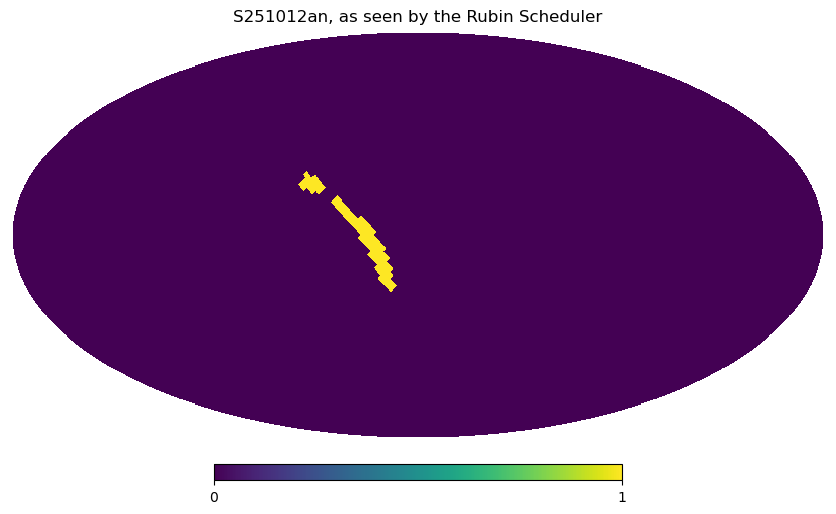

In [3]:
allMDCData = pd.read_csv("../mdc_data/mdc_Rubin_EFD_data.csv")
testEvent = allMDCData.iloc[-147]  # This is a good gold event to test with
testEvent = allMDCData.iloc[-150]  # This is a good silver event to test with
tst = np.zeros(len(makeSkymapArr(testEvent)))
preSorted = makeSkymapArr(testEvent)
for t, ind in zip(preSorted, range(len(preSorted))):
    tst[hp.nest2ring(32, ind)] = t
hp.mollview(tst, title=f"{testEvent['source']}, as seen by the Rubin Scheduler")

In [4]:
day_obs = getDayObsFromCSVEntry(testEvent, dateJust=-1)
sim_nights = getSimNightsFromCSVEntry(testEvent)
eventTriggerTime = np.datetime64(
    Time(testEvent["event_trigger_timestamp"]).to_datetime()
)

/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/815773890.py:40: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  dt = np.datetime64(event[dateColumn]) + np.timedelta64(dateJust, "D")


In [5]:
injectionDF = pd.read_csv("../mdc_data/injection_properties.csv")
injDec, injRa = injectionDF[injectionDF["superevent"] == testEvent["source"]][
    ["declination", "corrected_ra"]
].iloc[0]

In [6]:
testEvent["injRa"] = injRa
testEvent["injDec"] = injDec

/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1928672017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testEvent["injRa"] = injRa
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1928672017.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testEvent["injRa"] = injRa
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1928672017.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test

In [7]:
print(
    f"Total time from event trigger timestamp to receipt on summit: {np.timedelta64(np.datetime64(testEvent['EFD datetime']) - np.datetime64(testEvent['event_trigger_timestamp']),'ns')/np.timedelta64(1, 'ns') * 10**-9:.3f}s"
)

Total time from event trigger timestamp to receipt on summit: 296.139s


/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/952356050.py:2: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  f"Total time from event trigger timestamp to receipt on summit: {np.timedelta64(np.datetime64(testEvent['EFD datetime']) - np.datetime64(testEvent['event_trigger_timestamp']),'ns')/np.timedelta64(1, 'ns') * 10**-9:.3f}s"


## Secondary imports

I honestly do not know why the import structure has to be this way. It just does. I have tried other things, and it does not work. I would rather something work than neatly fail.

In [8]:
import getpass
import os
import warnings
import copy
import logging

logging.getLogger("lsst_survey_sim").setLevel(logging.INFO)
logging.getLogger("rubin_nights").setLevel(logging.INFO)

import numpy as np
import sqlite3
import healpy as hp
import matplotlib.pyplot as plt

plt.style.use("/Users/sean/.config/matplotlib/matplotlibrc")
import colorcet as cc
import skyproj
from IPython.display import display, HTML

import datetime
from astropy.coordinates import SkyCoord
import astropy.units as u

from rubin_scheduler.site_models import Almanac
from rubin_scheduler.scheduler import sim_runner
from rubin_scheduler.scheduler.schedulers import CoreScheduler
from rubin_scheduler.scheduler.features import Conditions
from rubin_scheduler.scheduler.utils import TargetoO, SimTargetooServer
from rubin_scheduler.utils import (
    ddf_locations,
    angular_separation,
    approx_ra_dec2_alt_az,
    Site,
    SURVEY_START_MJD,
)

import rubin_sim.maf as maf
from rubin_sim.data import get_baseline

from rubin_nights import connections
import rubin_nights.lfa_data as rn_lfa
import rubin_nights.dayobs_utils as rn_dayobs
import rubin_nights.plot_utils as rn_plots
import rubin_nights.augment_visits as augment_visits
import rubin_nights.rubin_scheduler_addons as rn_sch
import rubin_nights.rubin_sim_addons as rn_sim
import rubin_nights.observatory_status as observatory_status
import rubin_nights.scriptqueue as scriptqueue
import rubin_nights.scriptqueue_formatting as scriptqueue_formatting

import importlib

from lsst_survey_sim import lsst_support, simulate_lsst, plot

band_colors = rn_plots.PlotStyles.band_colors

# %load_ext memory_profiler

## Set up the scheduler, observatory, and other simulation configuration

### Set downtime, scheduler settings, and clouds.

In [9]:
# today_dayobs is the day of today - useful for checking if we're running in the past or not
today_dayobs = rn_dayobs.day_obs_str_to_int(rn_dayobs.today_day_obs())

# day_obs == the day to start the simulation
# Set in first cell

day_obs_time = rn_dayobs.day_obs_to_time(day_obs)
next_day_obs_time = rn_dayobs.day_obs_to_time(day_obs) + TimeDelta(1, format="jd")

next_day_obs = rn_dayobs.day_obs_str_to_int(
    rn_dayobs.time_to_day_obs(next_day_obs_time)
)

# Some parameters relating to downtime setup for model observatory
# In general, if only simulating one night, probably want no downtime or clouds
day_downtime = day_obs
if sim_nights == 1:
    add_downtime = False
    real_downtime = False
    add_clouds = False
else:
    add_downtime = True
    real_downtime = True
    add_clouds = True
# But could try to simulate previous nights to check if we recreate what happened
if day_obs <= today_dayobs:
    print("Checking the past, will restrict uptime to time acquiring science visits")
    add_downtime = True
    real_downtime = True
    add_clouds = False
    day_downtime = next_day_obs

print("Setting up to with downtimes like:")
print("add_downtime =", add_downtime)
print("real_downtime = ", real_downtime)
print("add_clouds = ", add_clouds)

survey_start = SURVEY_START_MJD
programs = ["BLOCK-365", "BLOCK-407", "BLOCK-408"]
print("Potential science programs : ", programs)


sunset, sunrise = rn_dayobs.day_obs_sunset_sunrise(day_obs, sun_alt=-12)
print(f"Simulation for {sim_nights} nights starting on :")
print(f"DayObs {day_obs}, -12 deg sunset {sunset.iso}, -12 deg sunrise {sunrise.iso}")

sunset18, sunrise18 = rn_dayobs.day_obs_sunset_sunrise(day_obs, sun_alt=-18)
print(
    f"DayObs {day_obs}, -18 deg sunset {sunset18.iso}, -18 deg sunrise {sunrise18.iso}"
)

Checking the past, will restrict uptime to time acquiring science visits
Setting up to with downtimes like:
add_downtime = True
real_downtime =  True
add_clouds =  False
Potential science programs :  ['BLOCK-365', 'BLOCK-407', 'BLOCK-408']
Simulation for 10 nights starting on :
DayObs 20251011, -12 deg sunset 2025-10-11 23:44:26.345, -12 deg sunrise 2025-10-12 09:15:23.482
DayObs 20251011, -18 deg sunset 2025-10-12 00:13:41.717, -18 deg sunrise 2025-10-12 08:46:08.749


### Establish EFD endpoint and obsenve branch versions

In [10]:
# Establish endpoint using tokenfile
endpoints = connections.get_clients(tokenfile=tokenfile, site=site)
# run branch
q = endpoints["obsenv"].select_top_n(
    "lsst.obsenv.run_branch", ["branch_name"], 1, time_cut=sunset
)
q2 = endpoints["obsenv"].select_time_series(
    "lsst.obsenv.run_branch", ["branch_name"], sunset, sunrise
)
runbranch = pd.concat([q, q2])
display(runbranch)
current_runbranch = runbranch.branch_name.iloc[-1]
print(f"Current run branch {current_runbranch}")
# configuration information
q = endpoints["efd"].select_top_n(
    "lsst.sal.Scheduler.logevent_configurationApplied",
    ["configurations", "salIndex", "private_origin", "url", "version"],
    1,
    time_cut=sunset,
    index=1,
)
q2 = endpoints["efd"].select_time_series(
    "lsst.sal.Scheduler.logevent_configurationApplied",
    ["configurations", "salIndex", "private_origin", "url", "version"],
    sunset,
    sunrise,
    index=1,
)
q = pd.concat([q, q2])


def strip_repo(x: pd.Series):
    return x.url.split("/")[-3]


def strip_version(x: pd.Series):
    return x.version.replace("heads/", "")


def strip_yaml(x: pd.Series):
    return x.configurations.split(",")[-1]


config_repo = q.apply(strip_repo, axis=1)
config_version = q.apply(strip_version, axis=1)
config_yaml = q.apply(strip_yaml, axis=1)
configs = pd.DataFrame(
    [config_repo, config_version, config_yaml],
    columns=q.index,
    index=["config_repo", "config_commit", "config_yaml"],
).T
current_commit = config_version.iloc[0]
display(configs)
print(f"Current commit {current_commit}")

,branch_name
time,
2025-09-22 18:39:56.991000+00:00,tickets/DM-52592


Current run branch tickets/DM-52592


,config_repo,config_commit,config_yaml
time,,,
2025-10-10 17:00:15.586761+00:00,ts_config_ocs,temp-0-gfb3d43bf3d,fbs_config_sv_survey.yaml


Current commit temp-0-gfb3d43bf3d


In [11]:
# Git checkout ts_config_scheduler and set the configs to use.
# .. have to sort something out about what happens if the repo isn't clean ..
do_git_stuff = False
if do_git_stuff:
    ts_commit = "develop"
    # ts_commit = current_commit
    simulate_lsst.get_configuration(ts_commit, clone_path=ts_config_scheduler_root)
config_script_path = os.path.join(
    ts_config_scheduler_root,
    "Scheduler/feature_scheduler/maintel/",
    "fbs_config_lsst_survey.py",
)
config_ddf_script_path = os.path.join(
    ts_config_scheduler_root, "Scheduler/ddf_gen/lsst_ddf_gen_block_407.py"
)

### Retrieve previous visits to start scheduler 

In [12]:
refresh_visits = False
opsim_dir = "../mdc_data"

if refresh_visits:
    # initial_opsim = simulate_lsst.fetch_previous_visits(next_day_obs, tokenfile=tokenfile, site='summit')
    initial_opsim = simulate_lsst.fetch_previous_visits(
        next_day_obs, tokenfile=tokenfile, site="usdf"
    )
    if initial_opsim is not None:
        with warnings.catch_warnings(record=True) as w:
            warnings.simplefilter("always")
            initial_opsim.to_hdf(os.path.join(opsim_dir, "opsim.h5"), key="visits")
else:
    initial_opsim = pd.read_hdf(os.path.join(opsim_dir, "opsim.h5"))

if initial_opsim is None:
    print("No visits found")
else:
    print(f"Found {len(initial_opsim)} visits")
    print(f"max day_obs in visits {initial_opsim.day_obs.max()}")
    print(f"will be running simulation for dayobs {day_obs}")

Found 2039 visits
max day_obs in visits 20251125
will be running simulation for dayobs 20251011


### Setting up the ToO server and making the ToO object

In [13]:
import pickle

try_toos = True
manual_too = True
if try_toos and (not manual_too):
    lookback = TimeDelta(8, format="jd")
    # toos = simulate_lsst.fetch_too_events(sunset - lookback, sunrise, site='summit')
    toos = simulate_lsst.fetch_too_events(sunset - lookback, sunrise)
    if toos is not None:
        with open("test_too.p", "wb") as f:
            pickle.dump(toos, f)
elif try_toos and manual_too:
    toos = []
    toos.append(makeTargetoO_object_mdc(0, testEvent))
    # Make the too object here

else:
    try:
        with open("test_too.p", "rb") as f:
            toos = pickle.load(f)
    except FileNotFoundError:
        toos = None

# modify
toos = toos[-1:]  # use only one ToO
toos[0].duration = 10.0

print(len(toos))
# Wrap up ToOs for sim target server - only last currently relevant
too_server = SimTargetooServer(toos)

1


### Setting up the band scheduler and scheduler configuration

In [14]:
# Configure band scheduler
band_scheduler = simulate_lsst.setup_band_scheduler()

# Check what bands it expects for day_obs?
conditions = Conditions(mjd=sunset.mjd)
print(f"Bands expected to be available {day_obs}", band_scheduler(conditions))

# Configure scheduler and add initial visits
start_from_snapshot = False
if start_from_snapshot:
    # Try last snapshot before start of this dayobs
    t_max_snapshot = day_obs_time
    topic = "lsst.sal.Scheduler.logevent_largeFileObjectAvailable"
    snapshots = endpoints["efd"].select_top_n(
        topic, ["url"], num=1, time_cut=t_max_snapshot, index=1
    )
    uri = snapshots["url"].iloc[-1]
    print(f"Fetching snapshot {uri}")
    starting_scheduler, summit_conditions = rn_lfa.get_scheduler_snapshot(
        uri, at_usdf=True
    )
    # Just check that these are the right kind of things
    assert isinstance(starting_scheduler, CoreScheduler)
    assert isinstance(summit_conditions, Conditions)
    nside = starting_scheduler.nside
    # have to do some footwork to update snapshot to where we expect to resume observations
    # we actually probably have to do this with target_visits ...
    # let's just use the last snapshot for now (we know this was the end of the ToO)

else:
    # Configure scheduler, pass it ToOs to set up ToOSurveys, and add previous observations.
    starting_scheduler, _, nside = simulate_lsst.setup_scheduler(
        config_script_path=config_script_path,
        config_ddf_script_path=config_ddf_script_path,
        day_obs=day_obs,
        band_scheduler=band_scheduler,
        too_server=too_server,
        initial_opsim=initial_opsim.query("day_obs < @day_obs"),
    )

Bands expected to be available 20251011 ['g', 'r', 'i', 'z']


INFO:lsst_survey_sim.simulate_lsst:b'hash files: /Users/sean/Desktop/Repos/ts_config_scheduler/Scheduler/ddf_gen/gen_ddf_presched_observations.py, /Users/sean/Desktop/Repos/ts_fbs_utils/python/lsst/ts/fbs/utils/maintel/lsst_ddf_presched.py\nPre computed DDF file /Users/sean/RubinUtils/rubin_sim_data/scheduler/ts_ddf_array_fedbbbe.npz already exists. Skipping...\n'
/Users/sean/.local/share/mamba/envs/surveySim/lib/python3.10/site-packages/rubin_scheduler/scheduler/surveys/base_survey.py:138: UserWarning: Survey DD: RGES_onseason has a tracking detailer but target_name,observation_reason or science_program also set (and will ignore).
  warnings.warn(
/Users/sean/.local/share/mamba/envs/surveySim/lib/python3.10/site-packages/rubin_scheduler/scheduler/surveys/base_survey.py:138: UserWarning: Survey DD: RGES_offseason has a tracking detailer but target_name,observation_reason or science_program also set (and will ignore).
  warnings.warn(
INFO:lsst_survey_sim.simulate_lsst:Received too_serv

### Setting up the observatory instance

In [15]:
# Could consider placing a single seeing value
swap_seeing = False
if swap_seeing:
    # The fill value for missing DIMM values is 1
    seeing = 1.0
else:
    seeing = None


starting_observatory, survey_info = simulate_lsst.setup_observatory(
    day_obs=day_downtime,
    nside=nside,
    add_downtime=add_downtime,
    add_clouds=add_clouds,
    seeing=seeing,
    real_downtime=False,  # MODIFIED
    # initial_opsim=initial_opsim, # MODIFIED
    too_server=too_server,
)

INFO:lsst_survey_sim.lsst_support:Max length of night 11.929379492998123 min length of night 7.869099263101816
INFO:lsst_survey_sim.lsst_support:Total nighttime 37635.35926199332, total downtime 2744.4869102403754, available time 34890.87235175294
INFO:lsst_survey_sim.lsst_support:Average availability 0.9280698335399592


In [16]:
mask_days = 100
print(f"Modeled availability over next {mask_days} nights")
mask = np.where(
    survey_info["dayobsmjd"] < rn_dayobs.day_obs_to_time(day_obs).mjd + mask_days
)
print("Total nighttime {}, ".format(survey_info["hours_in_night"][mask].sum()))
print("total downtime {}, ".format(survey_info["downtime_per_night"][mask].sum()))
print(
    "available time {}".format(
        survey_info["hours_in_night"][mask].sum()
        - survey_info["downtime_per_night"][mask].sum()
    )
)
print(
    "Average availability over {} days {}".format(
        mask_days,
        (
            survey_info["hours_in_night"][mask].sum()
            - survey_info["downtime_per_night"][mask].sum()
        )
        / survey_info["hours_in_night"][mask].sum(),
    )
)
print("Average availability over survey {}".format(survey_info["system_availability"]))

Modeled availability over next 100 nights
Total nighttime 1126.0298405326903, 
total downtime 461.25778784119757, 
available time 664.7720526914927
Average availability over 100 days 0.5903680602078977
Average availability over survey 0.9280698335399592


Illustrate survey downtime assumptions


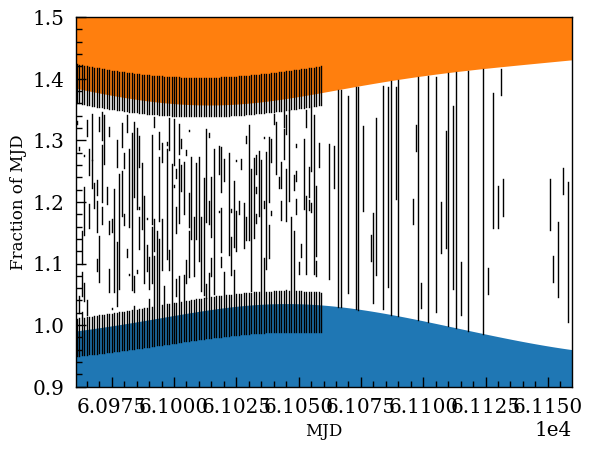

In [17]:
print("Illustrate survey downtime assumptions")
for start, end in survey_info["downtimes"]:
    x = np.floor(start - 0.5)
    plt.plot((x, x), (start - x, end - x), color="k")
x = np.floor(survey_info["sunsets12"] - 0.5)
y = survey_info["sunsets12"] - x
plt.fill_between(x, 0.8, y)
x = np.floor(survey_info["sunrises12"] - 0.5)
y = survey_info["sunrises12"] - x
plt.axvline(
    rn_dayobs.day_obs_to_time(day_obs).mjd, color="r", linestyle=":", linewidth=1.8
)
plt.fill_between(x, y, 1.6)
plt.ylim(0.9, 1.5)
plt.xlim(survey_info["survey_start"].mjd, rn_dayobs.day_obs_to_time(day_obs).mjd + 200)
plt.xlabel("MJD", fontsize="large")
_ = plt.ylabel("Fraction of MJD", fontsize="large")
# plt.savefig("onsky_downtime.png", bbox_inches='tight')

### Visualize DDF accessibility on first night of observations

In [18]:
check_ddfs = False
if check_ddfs:
    ddfs = ddf_locations(skycoords=True)
    lsst_site = Site("LSST")
    times = np.arange(
        survey_info["survey_start"].mjd, survey_info["survey_end"].mjd, 1 / 24
    )
    times = np.arange(
        np.floor(Time.now().mjd - 0.5), survey_info["survey_end"].mjd, 0.25 / 24
    )
    times = np.arange(sunset.mjd - 0.1, sunrise.mjd + 0.1, 0.05 / 24)
    sunmoon = survey_info["almanac"].get_sun_moon_positions(times)
    moon_ra = sunmoon["moon_RA"]
    moon_dec = sunmoon["moon_dec"]
    sun_alt = np.degrees(sunmoon["sun_alt"])
    ddf_moon_dist = {}
    ddf_alt = {}
    for ddf in ddfs:
        ddf_moon_dist[ddf] = angular_separation(
            ddfs[ddf].ra.deg,
            ddfs[ddf].dec.deg,
            np.degrees(moon_ra),
            np.degrees(moon_dec),
        )
        alt, az = approx_ra_dec2_alt_az(
            ddfs[ddf].ra.deg,
            ddfs[ddf].dec.deg,
            lsst_site.latitude,
            lsst_site.longitude,
            times,
            lmst=None,
        )
        ddf_alt[ddf] = alt

    plt.figure()
    for ddf in ddfs:
        mask = np.where((sun_alt <= -12) & (ddf_alt[ddf] > 40))
        plt.plot(
            Time(times[mask], format="mjd").to_datetime(),
            ddf_moon_dist[ddf][mask],
            marker=".",
            linestyle="",
            label=ddf,
        )
    plt.legend(loc=(1.01, 0.5))
    plt.axvline(sunset.to_datetime(), color="k", linestyle=":")
    plt.axvline(sunrise.to_datetime(), color="k", linestyle=":")
    plt.axhline(30)
    plt.xticks(rotation=90)
    plt.xlabel("MJD")
    plt.ylabel("Distance to moon (deg)")

    plt.figure()
    for ddf in ddfs:
        mask = np.where((sun_alt <= -12) & (ddf_alt[ddf] > 40))
        plt.plot(
            Time(times[mask], format="mjd").to_datetime(),
            ddf_alt[ddf][mask],
            marker=".",
            linestyle="",
            label=ddf,
        )
    plt.legend(loc=(1.01, 0.5))
    plt.axvline(sunset.to_datetime(), color="k", linestyle=":")
    plt.axvline(sunrise.to_datetime(), color="k", linestyle=":")
    plt.axhline(30)
    plt.xticks(rotation=90)
    plt.xlabel("MJD")
    plt.ylabel("Altitude (deg)")

### Reset the observatory and scheduler instance

In [19]:
reset = True
if reset:
    observatory = copy.deepcopy(starting_observatory)
    scheduler = copy.deepcopy(starting_scheduler)

## Execute the simulated observations

In [20]:
# Run the simulation for some nights
print("Running simulation")
observations, scheduler, observatory, rewards, obs_rewards, survey_info = (
    simulate_lsst.run_sim(
        scheduler=scheduler,
        # scheduler=starting_scheduler,
        band_scheduler=band_scheduler,
        observatory=observatory,
        # observatory=starting_observatory,
        survey_info=survey_info,
        day_obs=day_obs,
        sim_nights=sim_nights,
        keep_rewards=False,
    )
)

Running simulation


progress = 0.54%

/Users/sean/.local/share/mamba/envs/surveySim/lib/python3.10/site-packages/rubin_scheduler/skybrightness_pre/sky_model_pre.py:387: UserWarning: Sun high, using bright sky approx
  warnings.warn("Sun high, using bright sky approx")


progress = 0.99%

/Users/sean/.local/share/mamba/envs/surveySim/lib/python3.10/site-packages/rubin_scheduler/utils/healpy_utils.py:342: UserWarning: Can not connect to any more pixels.
  warnings.warn("Can not connect to any more pixels.")


progress = 55.78%

/Users/sean/.local/share/mamba/envs/surveySim/lib/python3.10/site-packages/rubin_scheduler/scheduler/features/features.py:530: UserWarning: Time must flow forwards to track the feature in NObservationsCurrentSeason.Not updating season_map.
  warnings.warn(


progress = 106.54%Skipped 0 observations
Flushed 6 observations from queue for being stale
Completed 5054 observations
ran in 0 min = 0.0 hours


In [21]:
# # # Need to start at a specific time inside the night?

# sunset, sunrise = rn_dayobs.day_obs_sunset_sunrise(day_obs, sun_alt=-12)
# start = sunset.mjd - 0.1/24
# start = (sunset + TimeDelta(60/60/24, format='jd')).mjd
# end = sunrise.mjd
# end = start + 4/24

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", RuntimeWarning)
#     vals = sim_runner(
#         observatory,
#         scheduler,
#         band_scheduler=band_scheduler,
#         sim_start_mjd=start,
#         sim_duration=end-start,
#         record_rewards=False,
#         verbose=True,
#     )
# observatory = vals[0]
# scheduler = vals[1]
# observations = vals[2]
# if len(vals) == 5:
#     rewards = vals[3]
#     obs_rewards = vals[4]

## All-sky visualizations

### Night of observations

In [22]:
targets = pd.DataFrame(observations)
if sim_nights < 3:

    from zoneinfo import ZoneInfo

    tz = ZoneInfo("Chile/Continental")
    tz_utc = ZoneInfo("UTC")
    telescope = "Simonyi"

    lsst_site = Site("LSST")
    almanac = Almanac()
    night_events = almanac.get_sunset_info(
        evening_date=rn_dayobs.day_obs_int_to_str(day_obs),
        longitude=lsst_site.longitude_rad,
    )

    def mjd_to_datetime(mjd, scale="utc", timezone=tz):
        return Time(mjd, format="mjd", scale=scale).utc.to_datetime(timezone=timezone)

    eps = 1
    fig, ax = plt.subplots(figsize=(13, 8))
    ax_utc = ax.twiny()

    ax.set_title(f"{telescope} DAYOBS {day_obs}", pad=20)

    # Shade astronomical events
    ax.fill_between(
        [
            mjd_to_datetime(night_events["sun_n12_setting"]),
            mjd_to_datetime(night_events["sun_n18_setting"]),
        ],
        2.5,
        0.0,
        color="lightgray",
        alpha=0.3,
    )
    ax.fill_between(
        [
            mjd_to_datetime(night_events["sunset"]),
            mjd_to_datetime(night_events["sun_n12_setting"]),
        ],
        2.5,
        0.0,
        color="gray",
        alpha=0.3,
    )
    ax.fill_between(
        [
            mjd_to_datetime(night_events["sun_n18_rising"]),
            mjd_to_datetime(night_events["sun_n12_rising"]),
        ],
        2.5,
        0.0,
        color="lightgray",
        alpha=0.3,
    )
    ax.fill_between(
        [
            mjd_to_datetime(night_events["sun_n12_rising"]),
            mjd_to_datetime(night_events["sunrise"]),
        ],
        2.5,
        0.0,
        color="gray",
        alpha=0.3,
    )
    # Azimuth constraint period
    ax.fill_between(
        [
            mjd_to_datetime(night_events["sunrise"] - 3 / 24),
            mjd_to_datetime(night_events["sun_n18_rising"]),
        ],
        2.5,
        0.0,
        color="pink",
        alpha=0.1,
    )

    if not np.isnan(night_events["moonrise"]):
        ax.axvline(
            mjd_to_datetime(night_events["moonrise"]),
            linestyle="-",
            color="blue",
            alpha=0.3,
        )
    if not np.isnan(night_events["moonset"]):
        ax.axvline(
            mjd_to_datetime(night_events["moonset"]),
            linestyle="-",
            color="red",
            alpha=0.3,
        )

    colors = cc.glasbey_category10
    # Assign distinct target sets with different colors
    marker_colors = {}
    marker_style = {}
    labels = {}
    count = 0
    if len(targets) > 0:
        for sp in targets.science_program.unique():
            if sp in programs:
                for obs in targets.observation_reason.unique():
                    marker_colors[obs] = colors[count]
                    marker_style[obs] = "o"
                    labels[obs] = obs
                    count += 1
            else:
                for sp in targets.science_program.unique():
                    marker_colors[sp] = colors[count]
                    marker_style[sp] = "^"
                    labels[sp] = sp
                    count += 1

    if len(targets) > 0:
        visit_alpha = 0.7
        for program in programs:
            q = targets.query("science_program == @program")
            for sp in q.observation_reason.unique():
                qq = q.query("observation_reason == @sp")
                label = sp
                ax.plot(
                    mjd_to_datetime(qq.mjd, "tai"),
                    qq.airmass,
                    marker=marker_style[sp],
                    linestyle="",
                    color=marker_colors[sp],
                    label=label,
                    alpha=visit_alpha,
                    markerfacecolor="none",
                    zorder=3,
                )
        # then the remainder
        q = targets.query("science_program not in @programs")
        for sp in q.science_program.unique():
            qq = q.query("science_program == @sp")
            label = sp
            ax.plot(
                mjd_to_datetime(qq.mjd, "tai"),
                qq.airmass,
                marker=marker_style[sp],
                linestyle="",
                color=marker_colors[sp],
                markersize=9,
                label=label,
                alpha=1,
                markerfacecolor="none",
                zorder=4,
            )

    # Add actual visits
    if len(initial_opsim) > 0:
        q = initial_opsim.query("day_obs == @day_obs")
        for b in q.band.unique():
            qq = q.query("band == @b")
            ax.plot(
                mjd_to_datetime(qq.observationStartMJD),
                qq.airmass,
                label=f"{b} science",
                alpha=0.6,
                marker=".",
                linestyle="",
                color=band_colors[b],
                zorder=0,
            )
        if len(q) > 0:
            print(
                f"Consdb reported {len(q)} visits. Simulation generated {len(targets)} visits."
            )

    ax.legend(loc=(1.01, 0.0), ncol=2)

    x0 = night_events["sunset"] + 30 / 60 / 24

    # ax.set_xlim(mjd_to_datetime(night_events['sunset']+30/60/24),
    #          mjd_to_datetime(night_events['sunrise']-30/60/24))
    # ax_utc.set_xlim(mjd_to_datetime(night_events['sunset']+30/60/24, 'utc', timezone=tz_utc),
    #          mjd_to_datetime(night_events['sunrise']-30/60/24, 'utc', timezone=tz_utc))

    # ax.set_xlim(mjd_to_datetime(night_events['sunset']+30/60/24),
    #          mjd_to_datetime(night_events['sunrise']-30/60/24))
    # ax_utc.set_xlim(mjd_to_datetime(night_events['sunset']+30/60/24, 'utc', timezone=tz_utc),
    #          mjd_to_datetime(night_events['sunrise']-30/60/24, 'utc', timezone=tz_utc))

    # Set ticks relevant sides
    ax.tick_params(axis="x", bottom=True, top=False, labelbottom=True, labeltop=False)
    ax_utc.tick_params(
        axis="x", bottom=False, top=True, labelbottom=False, labeltop=True
    )

    # Rotate and align bottom ticklabels
    plt.setp(
        [tick.label1 for tick in ax.xaxis.get_major_ticks()],
        rotation=45,
        ha="right",
        va="center",
        rotation_mode="anchor",
    )

    # Rotate and align top ticklabels
    plt.setp(
        [tick.label2 for tick in ax_utc.xaxis.get_major_ticks()],
        rotation=45,
        ha="left",
        va="center",
        rotation_mode="anchor",
    )

    plt.grid(True, alpha=0.2)

    plt.ylim(2.5, 0.9)

    ax.set_ylabel("Airmass", fontsize="large")
    ax.set_xlabel(f"Time ({tz})", fontsize="large")
    ax_utc.set_xlabel("Time (UTC)", fontsize="large")
    _ = plt.ylabel("Airmass", fontsize="large")

    print(f"current UTC time {Time.now().iso}")

### Image quality comparison

Comparison of model vs. actual seeing - for past nights only
Dayobs 20251011
DIMM mean FWHM 1.34


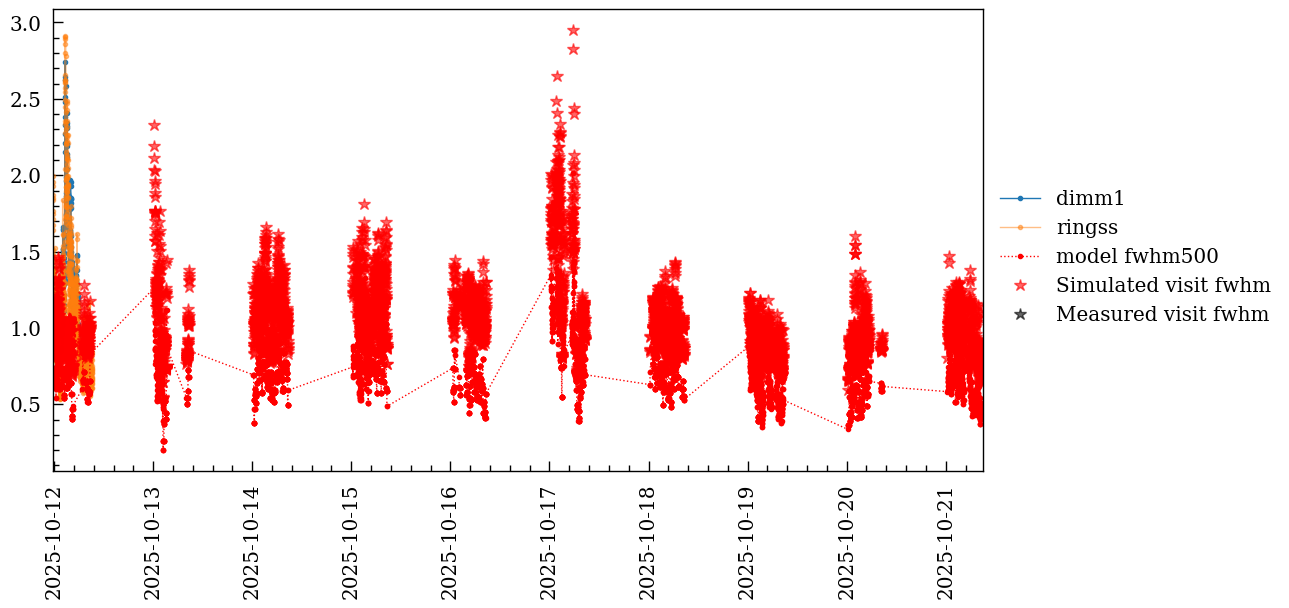

In [23]:
with_visits = True
only_visits = False
if day_obs <= today_dayobs:
    print("Comparison of model vs. actual seeing - for past nights only")

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    if not only_visits:
        dimm = endpoints["efd"].select_time_series(
            "lsst.sal.DIMM.logevent_dimmMeasurement", ["fwhm"], sunset, sunrise, index=1
        )
        if len(dimm) > 0:
            ax.plot(
                dimm.index,
                dimm.fwhm,
                linestyle="-",
                marker=".",
                linewidth=1,
                label="dimm1",
            )
            print(f"Dayobs {day_obs}")
            print(f"DIMM mean FWHM {dimm.fwhm.mean():.2f}")
        dimm2 = endpoints["efd"].select_time_series(
            "lsst.sal.DIMM.logevent_dimmMeasurement", ["fwhm"], sunset, sunrise, index=2
        )
        if len(dimm2) > 0:
            ax.plot(
                dimm2.index,
                dimm2.fwhm,
                linestyle="-",
                marker=".",
                linewidth=1,
                label="dimm2",
            )
        ringss = endpoints["efd"].select_time_series(
            "lsst.sal.ESS.logevent_ringssMeasurement",
            ["fwhmFree", "fwhmSector", "fwhmScintillation"],
            sunset,
            sunrise,
        )
        if len(ringss) > 0:
            ax.plot(
                ringss.index,
                ringss.fwhmFree,
                alpha=0.5,
                linestyle="-",
                marker=".",
                label="ringss",
            )
        # simulated dimm values
        ax.plot(
            Time(observations["mjd"], format="mjd").to_datetime(),
            observations["FWHM_500"],
            linestyle=":",
            marker=".",
            color="r",
            label="model fwhm500",
        )

    if with_visits:
        ax.plot(
            Time(observations["mjd"], format="mjd").to_datetime(),
            observations["FWHMeff"],
            "r*",
            markersize=9,
            linestyle="",
            alpha=0.6,
            label="Simulated visit fwhm",
        )
        q = initial_opsim.query("day_obs == @day_obs")
        ax.plot(
            Time(q.observationStartMJD, format="mjd").to_datetime(),
            q.seeingFwhmEff,
            "k*",
            markersize=9,
            linestyle="",
            alpha=0.6,
            label="Measured visit fwhm",
        )

    ax.legend(loc=(1.01, 0.3))

    _ = ax.set_xlim(
        Time(targets.mjd - 0.5 / 24, format="mjd").to_datetime().min(),
        Time(targets.mjd + 0.5 / 24, format="mjd").to_datetime().max(),
    )
    _ = plt.xticks(rotation=90)

### Visit gaps

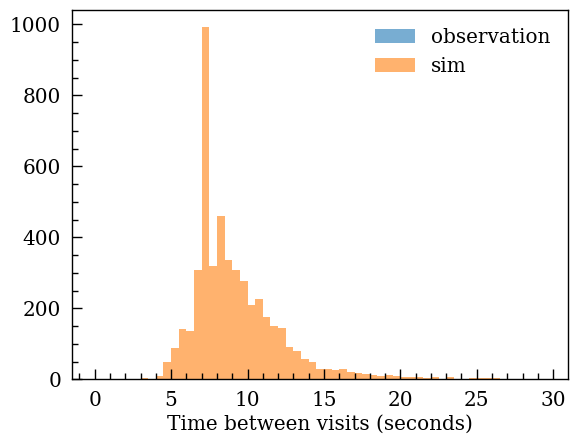

In [24]:
q = initial_opsim.query("day_obs == @day_obs")
obs_visit_gap = (
    (q.observationStartMJD[1:].values - q.obs_end_mjd[:-1].values) * 60 * 60 * 24
)
sim_visit_gap = (
    (
        observations["mjd"][1:]
        - (observations["mjd"][:-1] + observations["visittime"][:-1] / 60 / 60 / 24)
    )
    * 60
    * 60
    * 24
)
bins = np.arange(0, 30, 0.5)
_ = plt.hist(obs_visit_gap, bins=bins, alpha=0.6, label="observation")
_ = plt.hist(sim_visit_gap, bins=bins, alpha=0.6, label="sim")
plt.legend()
_ = plt.xlabel("Time between visits (seconds)")

### Map of sim visits, short simulation run only

In [25]:
# Make map on-sky of sim visits
print("Map of visits from this (sim, maybe also real) night only")
if sim_nights < 3:
    snvis = {}
    m_nvis = maf.CountMetric(col="mjd", metric_name="Nvisits")
    s = maf.HealpixSlicer(
        nside=64,
        lon_col="RA",
        lat_col="dec",
        rot_sky_pos_col_name="rotSkyPos",
        lat_lon_deg=False,
        verbose=False,
    )
    for b in ["all"]:
        constraint = f"{b}"
        if b == "all":
            opsvis = pd.DataFrame(observations).to_records()
        else:
            opsvis = pd.DataFrame(observations).query("band == @b").to_records()
        snvis[b] = maf.MetricBundle(m_nvis, s, constraint)
        g = maf.MetricBundleGroup({f"single night nvisits {b}": snvis[b]}, None)
        if len(opsvis) > 0:
            g.run_current(constraint, opsvis)

    background = plot.get_background(nside=64)
    mval = snvis["all"].metric_values
    vmax = np.percentile(mval.compressed(), 95)
    alpha = np.where(np.isnan(background), 0, background)
    alpha = np.where(alpha > 0.5, 0.5, alpha)
    alpha = np.where(mval.filled(0) > 0, 1, alpha)
    plot.hp_moll(
        mval.filled(0), alpha=alpha, vmin=0, vmax=vmax, label="Simulated night"
    )

# Make map on-sky of real visits
if sim_nights < 3 and day_obs <= today_dayobs:
    vnvis = {}
    m_nvis = maf.CountMetric(col="observationStartMJD", metric_name="Nvisits")
    s = maf.HealpixSlicer(
        nside=64,
        lon_col="fieldRA",
        lat_col="fieldDec",
        rot_sky_pos_col_name="rotSkyPos",
        lat_lon_deg=True,
        verbose=False,
    )
    for b in ["all"]:
        constraint = f"{b}"
        if b == "all":
            opsvis = pd.DataFrame(
                initial_opsim.query("day_obs == @day_obs")
            ).to_records()
        else:
            opsvis = (
                pd.DataFrame(observations)
                .query("day_obs == @day_obs and band == @b")
                .to_records()
            )
        vnvis[b] = maf.MetricBundle(m_nvis, s, constraint)
        g = maf.MetricBundleGroup({f"single night nvisits {b}": vnvis[b]}, None)
        if len(opsvis) > 0:
            g.run_current(constraint, opsvis)
    if vnvis["all"].metric_values is not None:
        mval = vnvis["all"].metric_values
        vmax = np.percentile(mval.compressed(), 95)
        plot.hp_moll(
            mval.filled(0), alpha=alpha, vmin=0, vmax=vmax, label="Consdb night"
        )

Map of visits from this (sim, maybe also real) night only


### Add observations to test database

In [26]:
filename = "test.db"
if False:  # sim_nights == 1:
    # Only new observations?
    obsdf = lsst_support.save_opsim(
        observatory, observations, initial_opsim=None, filename=filename
    )
else:
    # All observations?
    obsdf = lsst_support.save_opsim(
        observatory, observations, initial_opsim=initial_opsim, filename=filename
    )


def add_dayobs(x):
    mjdfloor = Time(
        np.floor(x.observationStartMJD - 0.5) + 0.5, format="mjd", scale="tai"
    )
    return rn_dayobs.day_obs_str_to_int(mjdfloor.isot.split("T")[0])


obsdf["day_obs"] = obsdf.apply(add_dayobs, axis=1)

### Check regions, science programs, and obs reasons

In [27]:
# Check all visits have metadata
print("Regions observed", split_regions(obsdf.target_name.unique()))
print("Science programs", obsdf.science_program.unique())
print("Observation Reasons / Surveys", np.sort(obsdf.observation_reason.unique()))

Regions observed ['GW_case_D_E_0', 'LMC_SMC', 'ddf_ecdfs', 'ddf_edfs_a', 'ddf_edfs_b', 'ddf_elaiss1', 'ddf_xmm_lss', 'dusty_plane', 'euclid_overlap', 'lowdust', 'nes', 'scp']
Science programs ['BLOCK-407' 'BLOCK-408' 'BLOCK-T630']
Observation Reasons / Surveys ['ddf_ecdfs' 'ddf_edfs_a' 'ddf_edfs_b' 'ddf_elaiss1' 'ddf_xmm_lss'
 'pairs_iz_15.0' 'pairs_iz_33.0' 'pairs_ri_15.0' 'pairs_zy_15.0'
 'pairs_zy_33.0' 'singles_r' 'singles_y' 'singles_z'
 'template_blob_g_33.0' 'template_blob_i_33.0' 'template_blob_r_33.0'
 'template_blob_y_33.0' 'template_blob_z_33.0' 'too_GW_case_D_E_0_i0'
 'too_GW_case_D_E_0_i1' 'too_GW_case_D_E_0_i2' 'too_GW_case_D_E_0_i3'
 'triplet_pairs_iz_33.0']






### Comparison to baseline survey plot

In [28]:
compare_baseline = False
if compare_baseline:
    # compare to baseline at same number of nights (increasingly bad comparison right now)
    opsdb = get_baseline()
    sim_name = opsdb.split("/")[-1].replace(".db", "")
    conn = sqlite3.connect(opsdb)
    b_visits = pd.read_sql(f"select * from observations where night < 365", conn)

    tconsdb = obsdf.observationStartMJD.max() - obsdf.observationStartMJD.min()
    print(f"comparing visits within {tconsdb} days of start")
    baseline_visits = b_visits.query(
        "observationStartMJD - observationStartMJD.min() < @tconsdb"
    )

    xx = (
        baseline_visits.groupby("observation_reason")
        .agg({"observationStartMJD": "count"})
        .rename({"observationStartMJD": sim_name}, axis=1)
    )
    xa = (
        obsdf.groupby("observation_reason")
        .agg({"observationStartMJD": "count"})
        .rename({"observationStartMJD": "sim config"}, axis=1)
    )
    print(len(baseline_visits), len(obsdf), len(obsdf) / len(baseline_visits))
    x = pd.concat([xa, xx], axis=1)
    x.loc["total"] = x.sum(axis=0)
    display(x)

### ddf visit table

In [29]:
ddf_visits = obsdf.query(
    "observation_reason.str.contains('DD') or observation_reason.str.contains('ddf')"
).copy()
if len(ddf_visits) > 0:
    print("n visits per band")
    ddf_visits.loc[:, "observation_reason"] = ddf_visits.observation_reason.str.lower()
    ss = ddf_visits.groupby(["observation_reason", "band"]).agg(
        {"observationStartMJD": "count"}
    )
    ss = ss.reset_index("band").pivot(columns=["band"]).droplevel(0, axis=1)
    ss["all"] = ss.sum(axis=1)
    order = ["u", "g", "r", "i", "z", "y", "all"]
    display(
        ss.query("observation_reason.str.contains('dd')")[
            [o for o in order if o in ss.columns]
        ]
    )

    print("n days per band")
    ss = ddf_visits.groupby(["observation_reason", "band"]).agg({"day_obs": "nunique"})
    ss = ss.reset_index("band").pivot(columns=["band"]).droplevel(0, axis=1)
    ss["all"] = ddf_visits.groupby("observation_reason").agg({"day_obs": "nunique"})
    display(
        ss.query("observation_reason.str.contains('dd')")[[o for o in order if o in ss]]
    )

n visits per band


band,g,r,i,z,y,all
observation_reason,,,,,,
ddf_ecdfs,6,4,6,4,2,22
ddf_edfs_a,6,3,4,3,4,20
ddf_edfs_b,6,3,4,3,4,20
ddf_elaiss1,15,4,11,4,14,48
ddf_xmm_lss,6,4,6,2,6,24


n days per band


band,g,r,i,z,y,all
observation_reason,,,,,,
ddf_ecdfs,3,2,3,2,1,6
ddf_edfs_a,4,2,3,2,2,7
ddf_edfs_b,4,2,3,2,2,7
ddf_elaiss1,5,2,4,2,4,7
ddf_xmm_lss,3,1,3,1,2,4


### Downselecting the ToO observations, here for gw events

In [30]:
ToO_obs_df = obsdf[[x.lower().__contains__("gw") for x in obsdf["observation_reason"]]]
ToO_bands = np.unique(ToO_obs_df["band"])
ToO_bands_plusAll = np.append(ToO_bands, "all")

In [31]:
def plot_band_visits(
    nvisits,
    bands,
    event_metadata,
    plot_tool,
    out_dir=".",
    save=False,
    nside=64,
    plotType="mcbryde",
    title=None,
    perNight=False,
    nights=None,
    makeHist=False,
    reverseStats=False
):
    """
    Generates and saves a multi-panel plot showing nvisits per band.

    Parameters:
    - nvisits: Dictionary of metric results per band.
    - bands: List of bands to plot (e.g., ['u', 'g', 'r']).
    - event_metadata: Dictionary containing 'source' info for filename.
    - plot_tool: The plotting object/module (containing get_background and make_plot).
    - out_dir: Directory to save the resulting image.
    - nside: Resolution for the background map.
    """

    # Checking here if any bands are not observed during the sim run

    if bands == ["all"]:
        observed_bands = bands
    else:
        bandMask = np.array([nvisits[b].metric_values != None for b in bands])

        for i, t in enumerate(bandMask):
            if type(t) != bool:
                bandMask[i] = True
        bandMask = bandMask.astype(bool)
        observed_bands = np.array(bands)[bandMask]

    background = plot_tool.get_background(nside=nside)
    num_bands = len(observed_bands)

    if perNight == None:
        num_nights = len(nights)
        num_rows = num_nights
    else:
        num_nights = 1
        num_rows = 1

    if makeHist:
        num_rows *= 2

    # Create the figure and axes
    fig, ax = plt.subplots(
        nrows=num_rows, ncols=num_bands, figsize=(5.3 * num_bands, 5 * num_rows)
    )

    # Handle the case where there's only one band (ax won't be an array)
    if num_bands == 1 and num_rows == 1:
        ax = [ax]

    if makeHist:
        axdict = {b: ax[0, i] for i, b in enumerate(observed_bands)}
        axdict_hist = {b: ax[1, i] for i, b in enumerate(observed_bands)}
    else:
        axdict = {b: ax[i] for i, b in enumerate(observed_bands)}

    for b in observed_bands:
        # Skip if no data
        if nvisits[b].metric_values is None:
            continue

        compressed_data = nvisits[b].metric_values.compressed()

        # Calculate scaling
        if len(compressed_data) > 1:
            vmax = np.nanpercentile(compressed_data, 95)
        else:
            vmax = None

        # Only label Dec for the first plot in the row
        label_dec = b == observed_bands[0]

        subtitle = ""  # Placeholder to handle multi-night instances
        subtitle += f"LSSTCam band {b}"

        fig, sp = plot_tool.make_plot(
            nvisits[b],
            background=background,
            proj=plotType,
            vmax=vmax,
            ax=axdict[b],
            title=subtitle,
            label_dec=label_dec,
        )

        sp.ax.plot(
            np.rad2deg(event_metadata["injRa"]),
            np.rad2deg(event_metadata["injDec"]),
            marker="+",
            color="red",
            markersize=5,
        )

        

        if makeHist:
            # Make the histogram
            _min = np.nanmin(compressed_data)
            _max = np.nanmax(compressed_data)
            if nvisits[b].metric.name == "Nvisits":
                bins = np.arange(_min, _max + 1, step=1)
            else:
                bins = np.arange(
                    _min, _max + (_max - _min) / 50, step=(_max - _min) / 50
                )
            axdict_hist[b].hist(compressed_data, bins=bins, histtype="step")
            percs = []
            percValues = [5, 50, 95]
            percText = ""
            for percVal in [5, 50, 95]:
                perc = np.nanpercentile(compressed_data, percVal)
                percs.append(perc)
                axdict_hist[b].axvline(perc, color="black")
            
            if reverseStats:
                percIterate = percValues
                percValsText = percs[::-1]
            else:
                percIterate = percValues
                percValsText = percs
            for pval,perc in zip(percIterate,percValsText):
                percText += f"{pval}%: {perc:.2f} "
            
            axdict_hist[b].set_title(percText)
            axdict_hist[b].set_ylabel(f"Healpix [NSide={hp.get_nside(nvisits[b].metric_values.data)}] / bin")

    if title != None:
        title+=f"\nCandidate coordinates: ({np.rad2deg(event_metadata['injRa']):.3f}º,{np.rad2deg(event_metadata['injDec']):.3f}º)"
        fig.suptitle(title)

    fig.tight_layout()

    # Construct filename and save
    source_name = event_metadata.get("source", "unknown")
    file_path = os.path.join(out_dir, f"lsstcam_nvisits_band_{source_name}.png")
    if save:
        fig.savefig(file_path, bbox_inches="tight")

    return fig, ax

### Make NVisit and 5$\sigma$ calculations for all observations

In [32]:
run_calc = True
if run_calc:
    nvisits = {}
    coadd = {}
    m_nvis = maf.CountMetric(col="observationStartMJD", metric_name="Nvisits")
    m_coadd = maf.Coaddm5Metric(m5_col="fiveSigmaDepth")
    s = maf.HealpixSlicer(
        nside=64,
        lon_col="fieldRA",
        lat_col="fieldDec",
        rot_sky_pos_col_name="rotSkyPos",
    )
    for b in ["u", "g", "r", "i", "z", "y", "all"]:
        constraint = f"{b}"
        if b == "all":
            opsvis = obsdf.to_records()
        else:
            opsvis = obsdf.query("band == @b").to_records()
        nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
        coadd[b] = maf.MetricBundle(m_coadd, s, constraint)
        g = maf.MetricBundleGroup(
            {f"nvisits {b}": nvisits[b], f"coadd {b}": coadd[b]}, None
        )
        if len(opsvis) > 0:
            g.run_current(constraint, opsvis)

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


### Plot 5$\sigma$ and visit maps for all observations

/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])


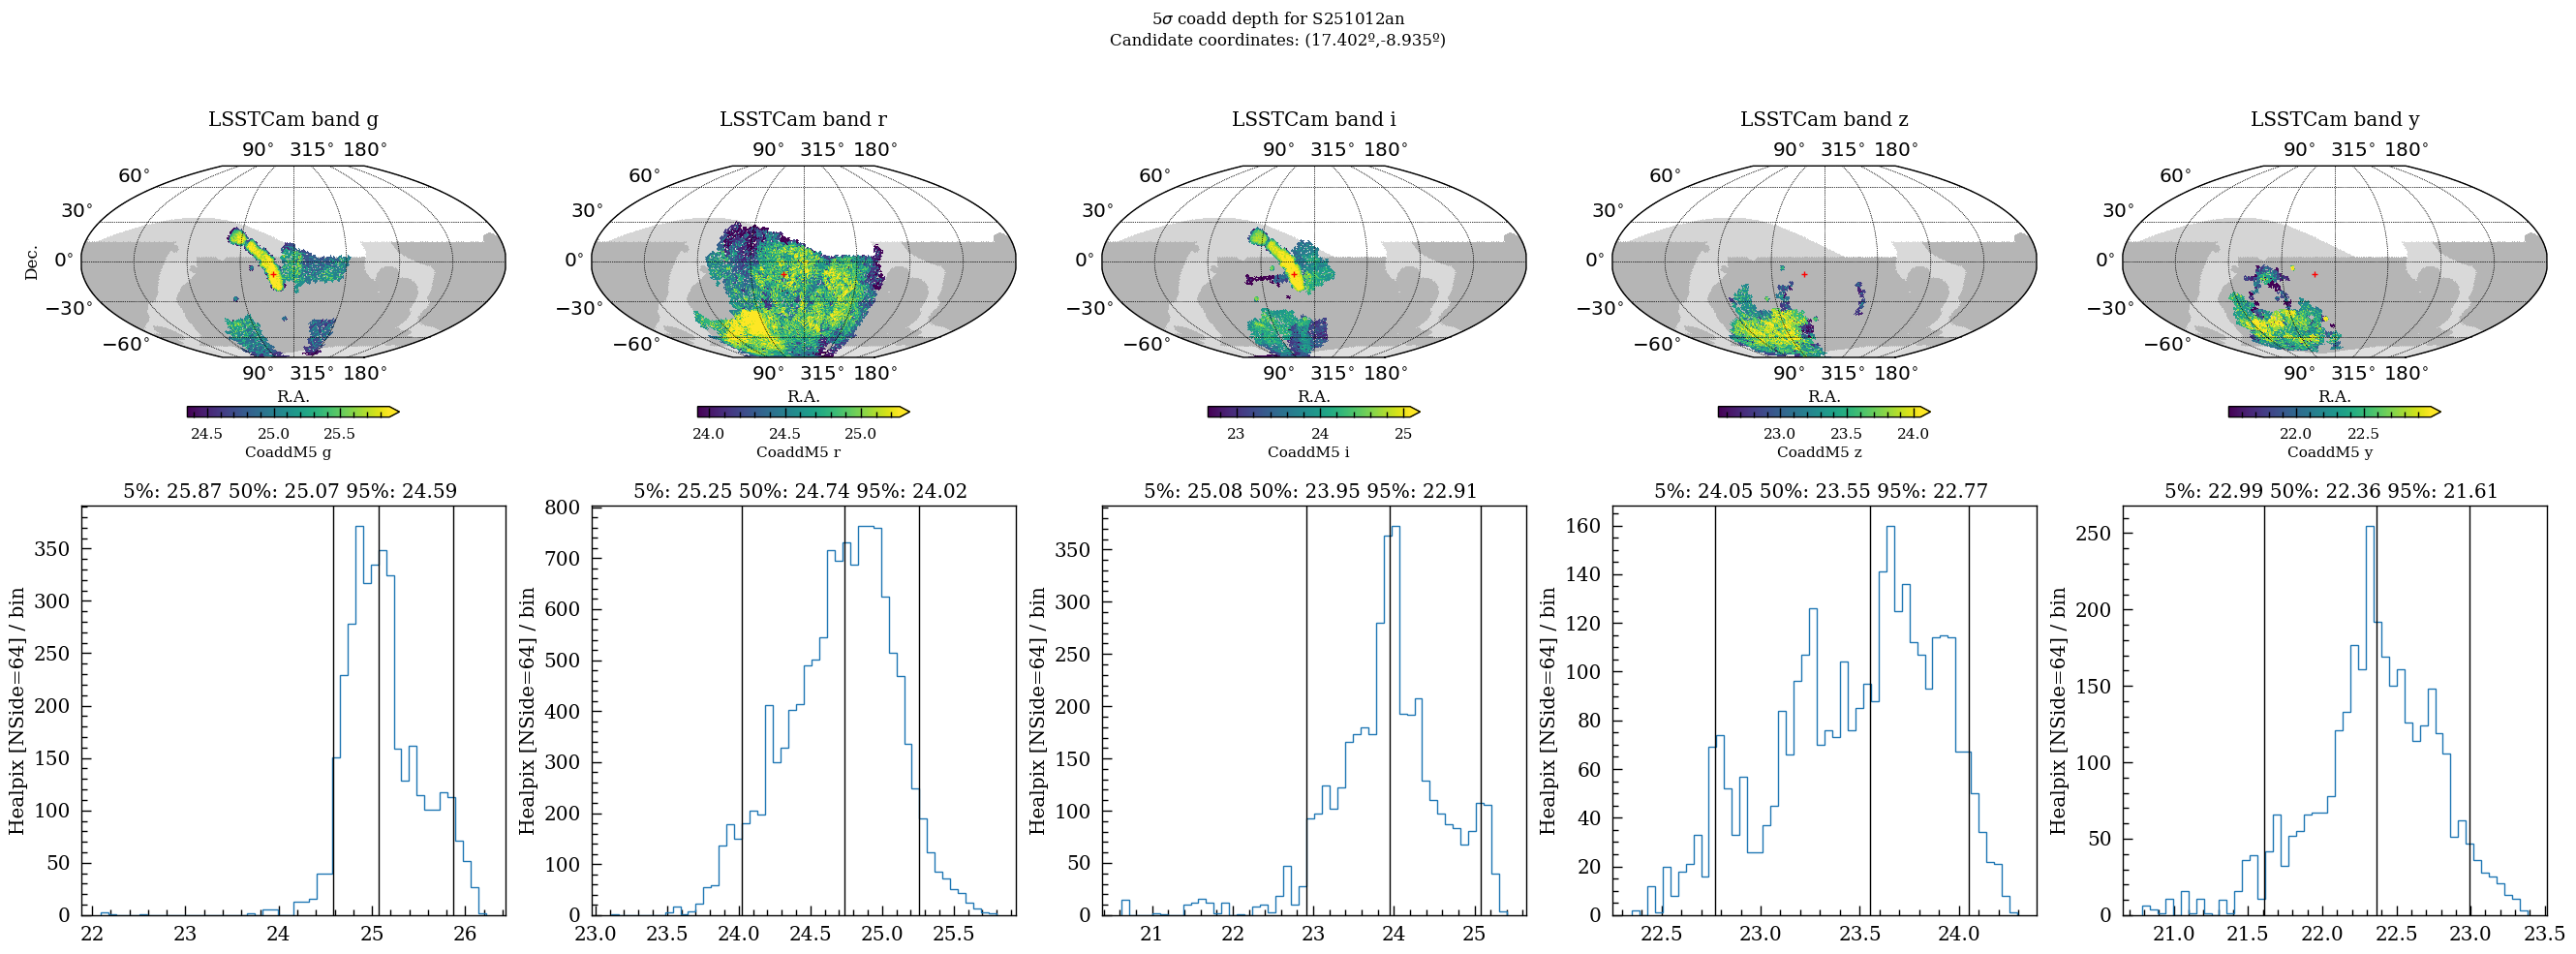

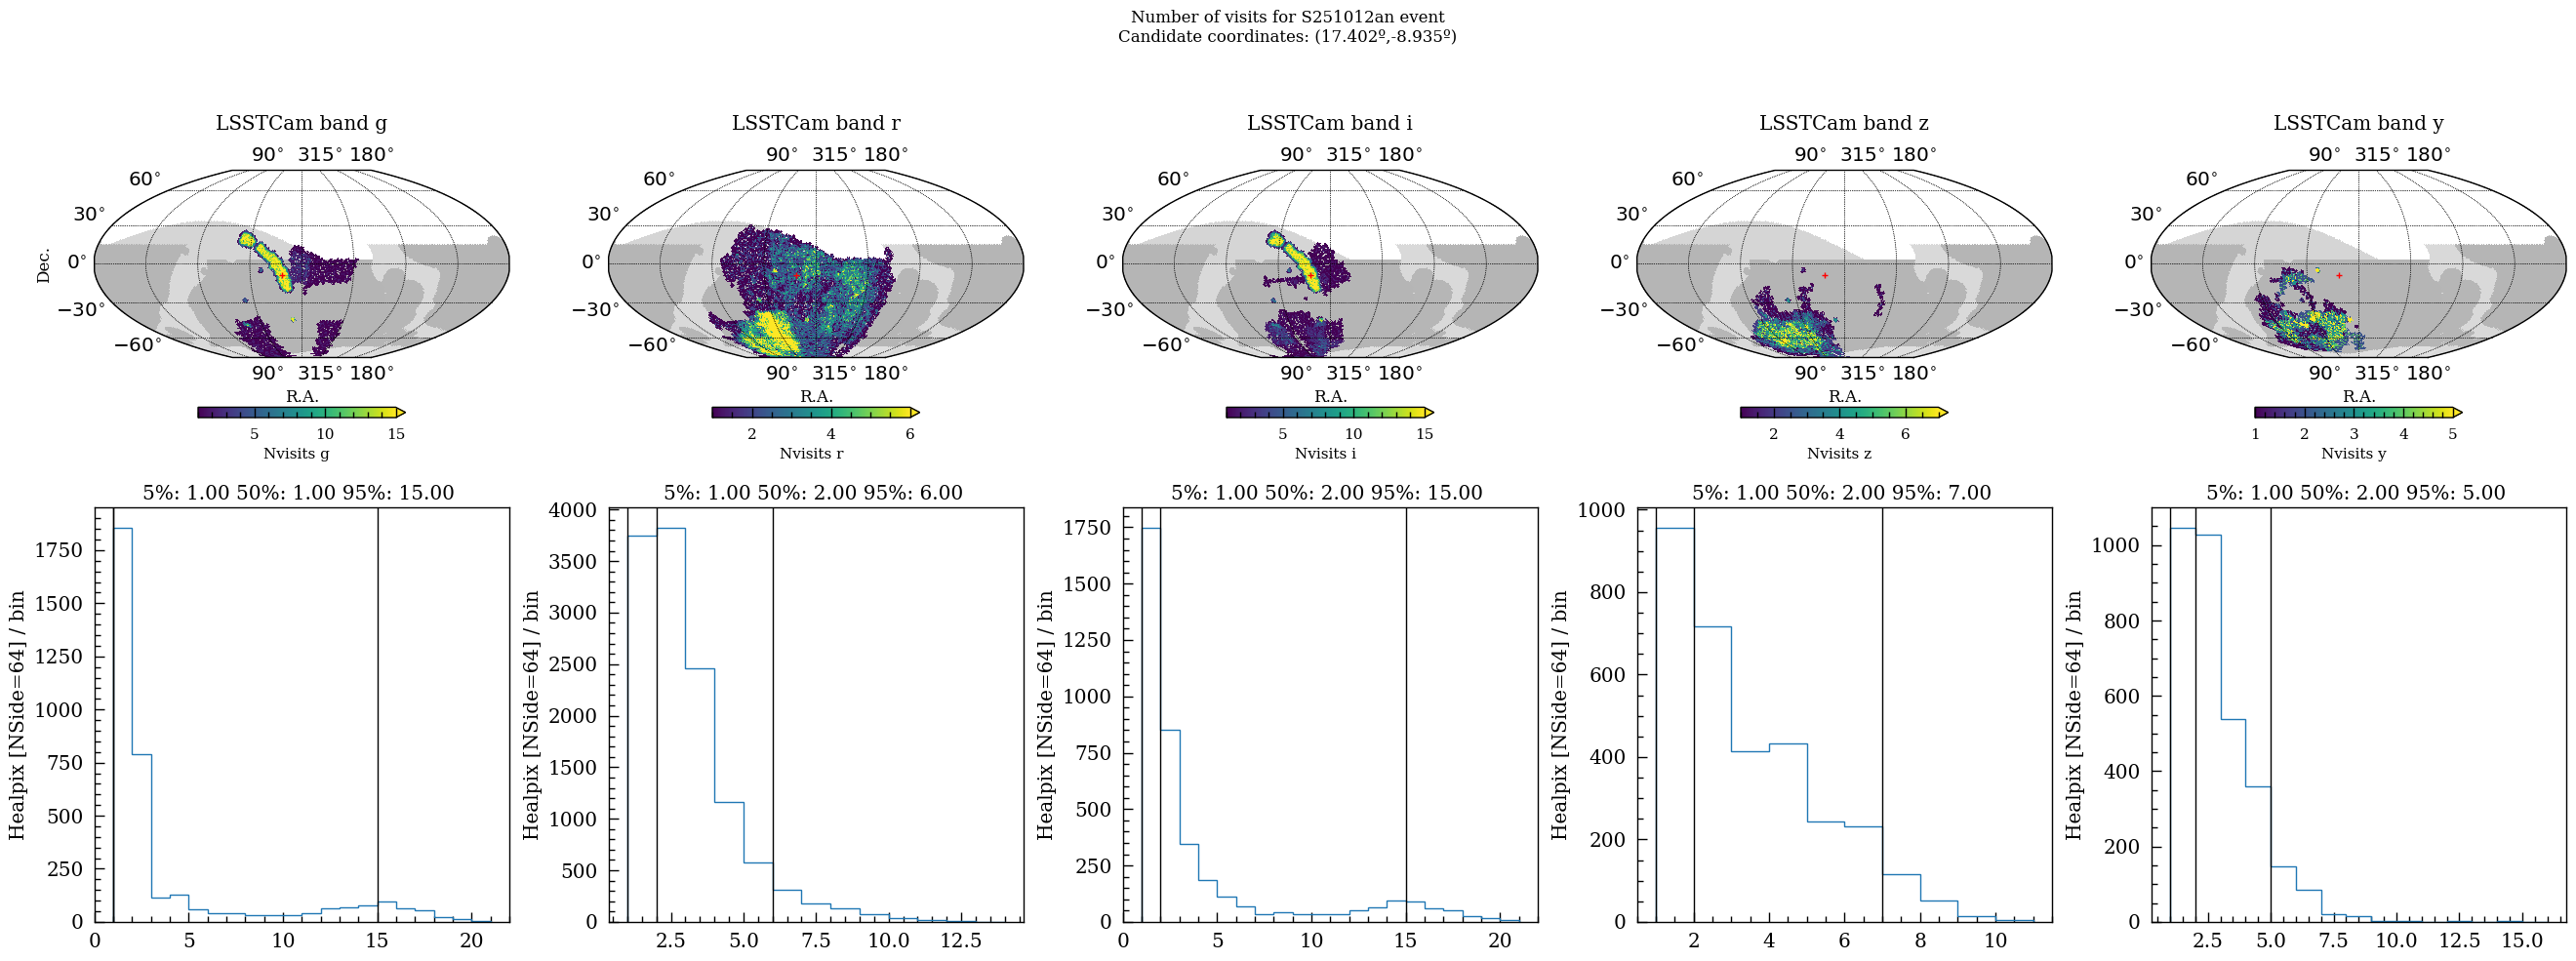

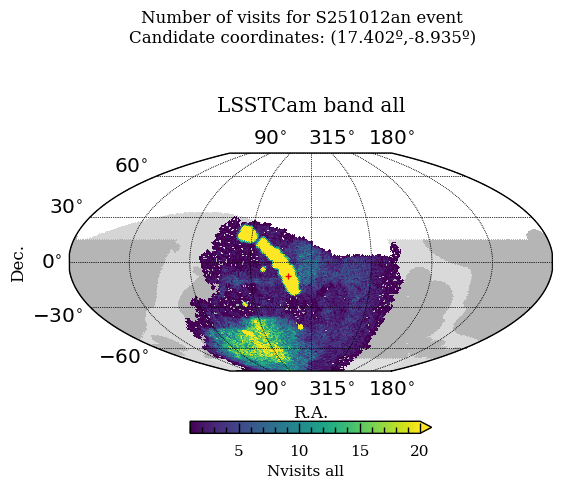

In [33]:
fig, ax = plot_band_visits(
    coadd,
    ["u", "g", "r", "i", "z", "y"],
    testEvent,
    plot,
    out_dir=".",
    save=False,
    nside=64,
    plotType="mcbryde",
    title=f"5$\sigma$ coadd depth for {testEvent['source']}",
    makeHist=True,
    reverseStats=True
)
fig = plot_band_visits(
    nvisits,
    ["u", "g", "r", "i", "z", "y"],
    testEvent,
    plot,
    out_dir=".",
    save=False,
    nside=64,
    plotType="mcbryde",
    title=f"Number of visits for {testEvent['source']} event",
    makeHist=True,
)
fig = plot_band_visits(
    nvisits,
    ["all"],
    testEvent,
    plot,
    out_dir=".",
    save=False,
    nside=64,
    plotType="mcbryde",
    title=f"Number of visits for {testEvent['source']} event",
    makeHist=False,
)

### Make NVisit and 5$\sigma$ calculations on ToO only visits, all nights combined

In [34]:
# This is to filter on ToO Obs
run_calc = True
if run_calc:
    nvisits = {}
    coadd = {}
    m_nvis = maf.CountMetric(col="observationStartMJD", metric_name="Nvisits")
    m_coadd = maf.Coaddm5Metric(m5_col="fiveSigmaDepth")
    s = maf.HealpixSlicer(
        nside=64,
        lon_col="fieldRA",
        lat_col="fieldDec",
        rot_sky_pos_col_name="rotSkyPos",
    )
    for b in ["u", "g", "r", "i", "z", "y", "all"]:  # Change
        constraint = f"{b}"
        if b == "all":
            opsvis = ToO_obs_df.to_records()
        else:
            opsvis = ToO_obs_df.query("band == @b").to_records()
        nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
        coadd[b] = maf.MetricBundle(m_coadd, s, constraint)
        g = maf.MetricBundleGroup(
            {f"nvisits {b}": nvisits[b], f"coadd {b}": coadd[b]}, None
        )
        if len(opsvis) > 0:
            g.run_current(constraint, opsvis)

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


### Plot of nVisits and 5$\sigma$ for ToO only visits, over all nights

/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])


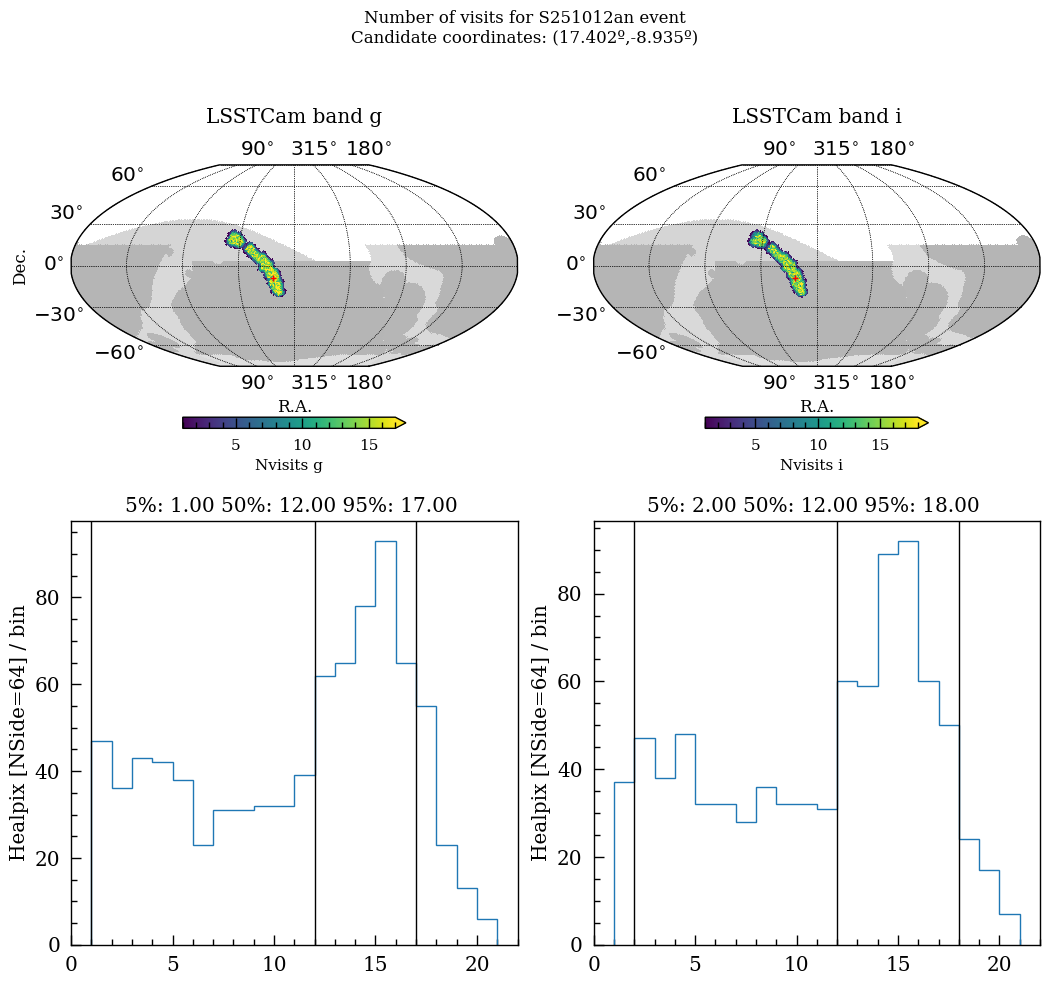

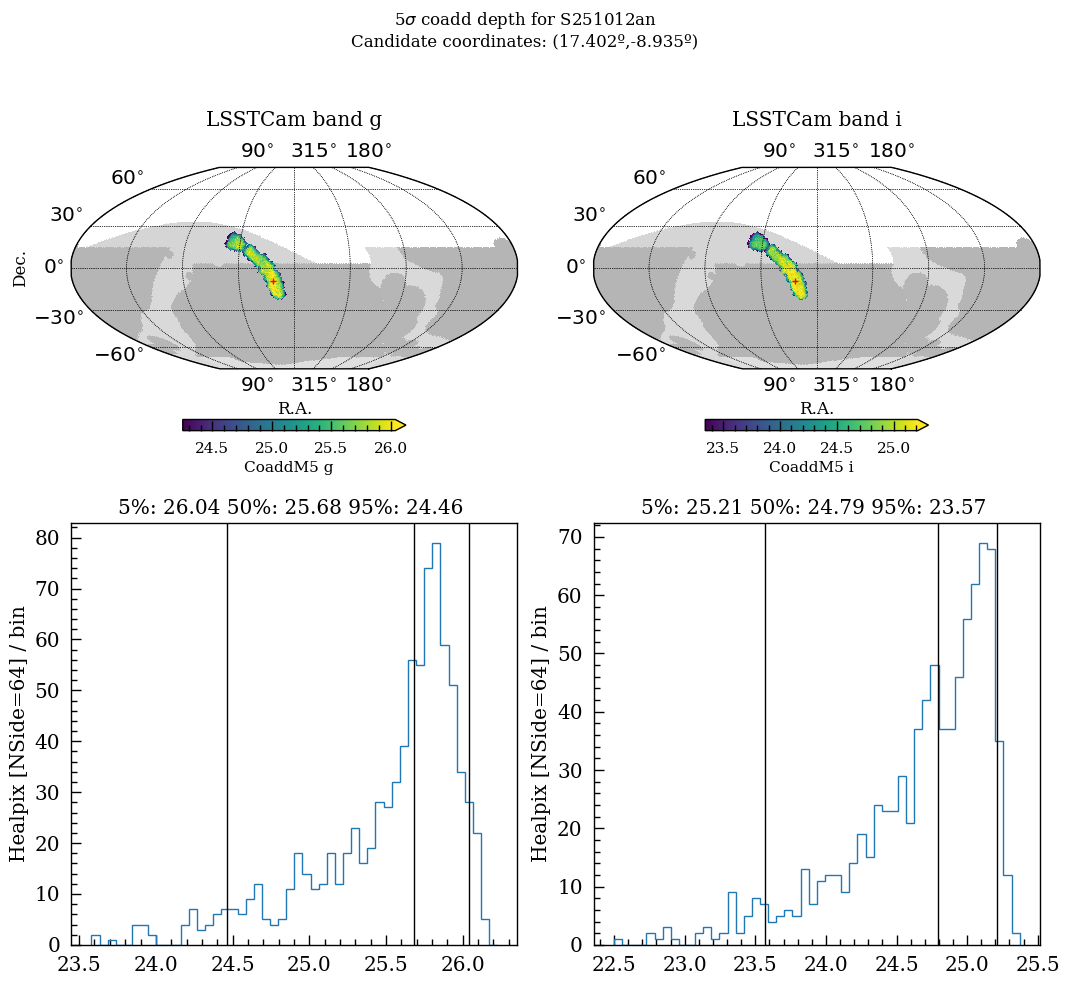

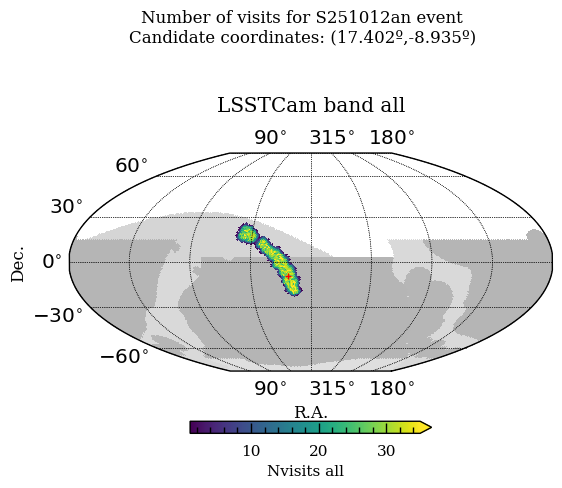

In [35]:
fig1 = plot_band_visits(
    nvisits,
    ["u", "g", "r", "i", "z", "y"],
    testEvent,
    plot,
    out_dir=".",
    save=False,
    nside=64,
    plotType="mcbryde",
    title=f"Number of visits for {testEvent['source']} event",
    makeHist=True,
)
fig2 = plot_band_visits(
    coadd,
    ["u", "g", "r", "i", "z", "y"],
    testEvent,
    plot,
    out_dir=".",
    save=False,
    nside=64,
    plotType="mcbryde",
    title=f"5$\sigma$ coadd depth for {testEvent['source']}",
    makeHist=True,
    reverseStats=True
)
fig3 = plot_band_visits(
    nvisits,
    ["all"],
    testEvent,
    plot,
    out_dir=".",
    save=False,
    nside=64,
    plotType="mcbryde",
    title=f"Number of visits for {testEvent['source']} event",
    makeHist=False,
)

### Make NVisit and 5$\sigma$ calculations on ToO only visits, separated by night

In [36]:
ToODF = targets[[x.__contains__("GW_case") for x in targets["target_name"]]]
testTime = Time(ToODF["mjd"], format="mjd").to_datetime()
numpyTimeArr = testTime.astype(np.datetime64)
ToO_obs_days = np.unique(
    [np.datetime_as_string(x, unit="D").replace("-", "") for x in numpyTimeArr]
)
day_obs, ToO_obs_days, eventTriggerTime

(20251011,
 array(['20251013', '20251014', '20251015', '20251016', '20251017'],
       dtype='<U8'),
 numpy.datetime64('2025-10-12T05:24:08.023000'))

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])


Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])


Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])


Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])


Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])
/var/folders/d8/d_92b22d1r57n7wy2ct3n7xr0000gn/T/ipykernel_6676/1810434839.py:33: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  bandMask = np.array([nvisits[b].metric_values != None for b in bands])


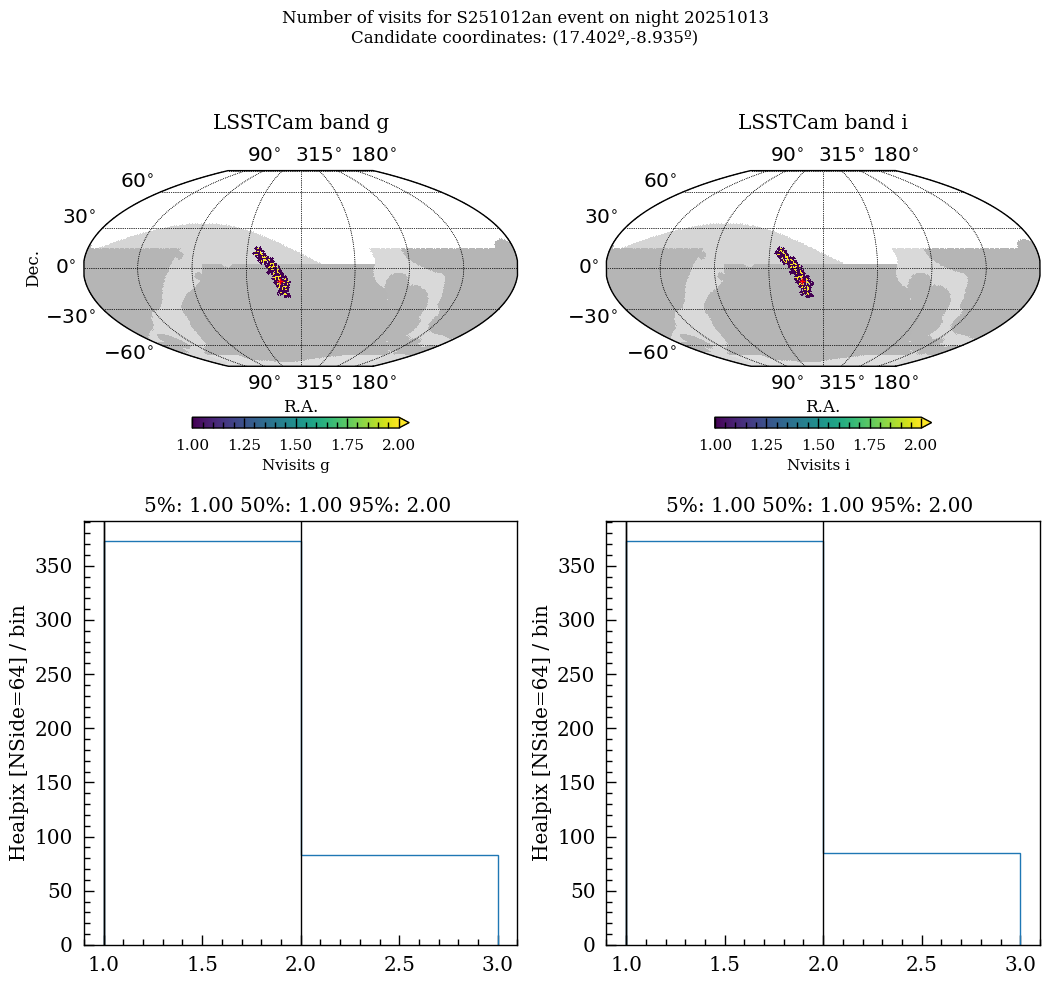

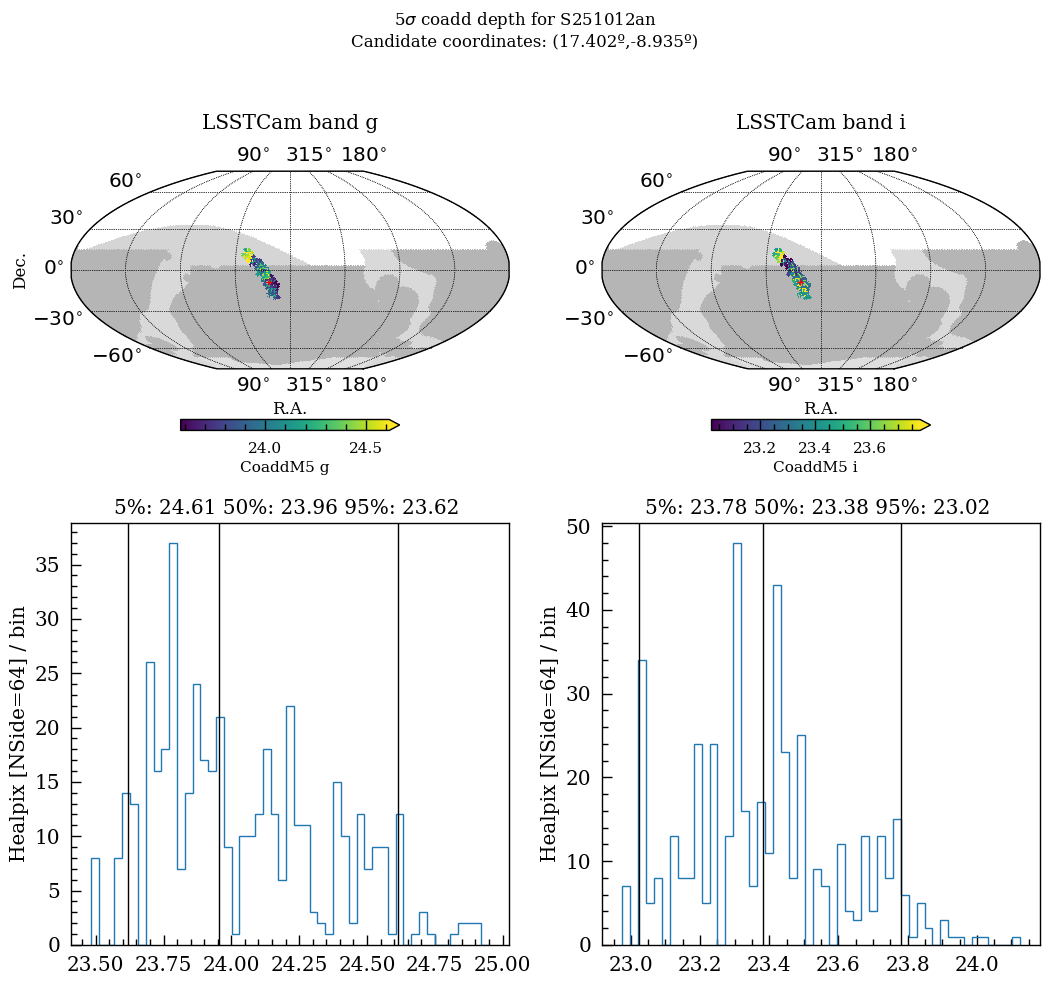

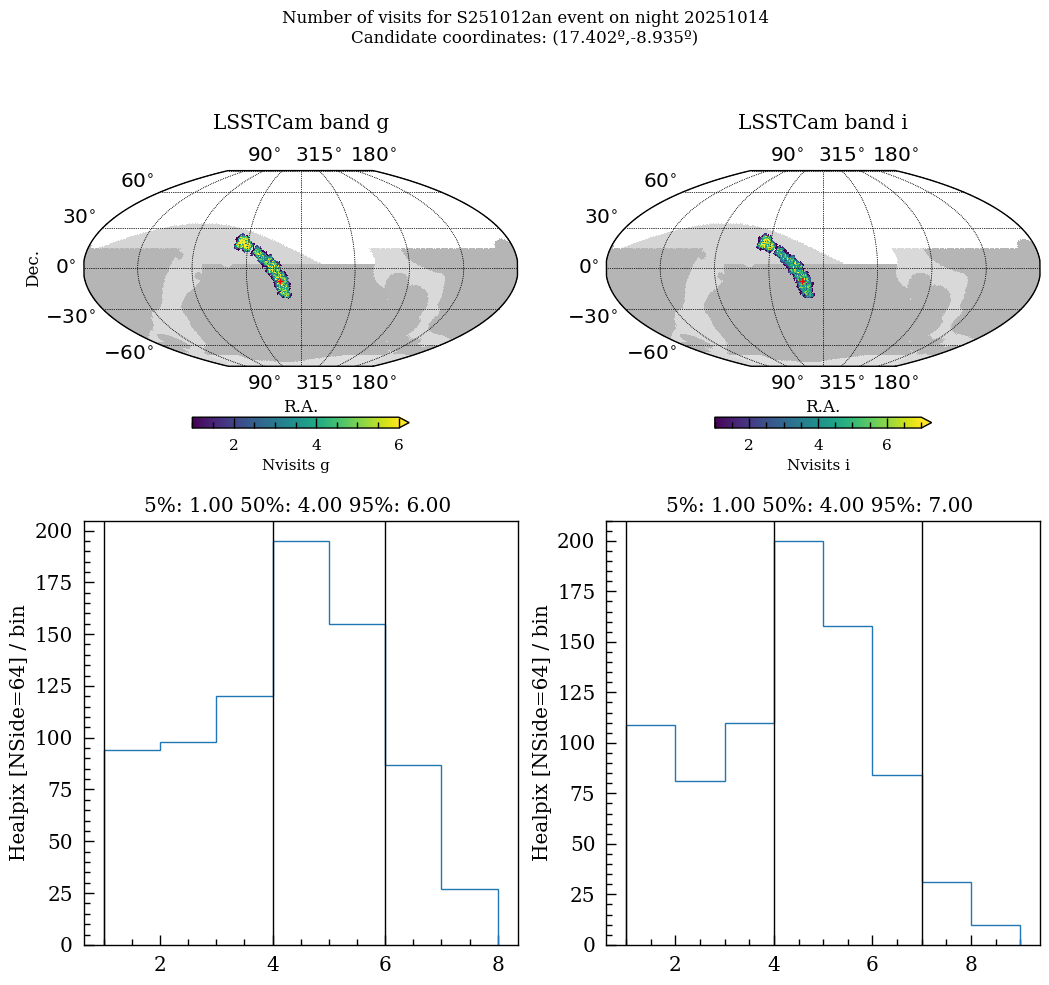

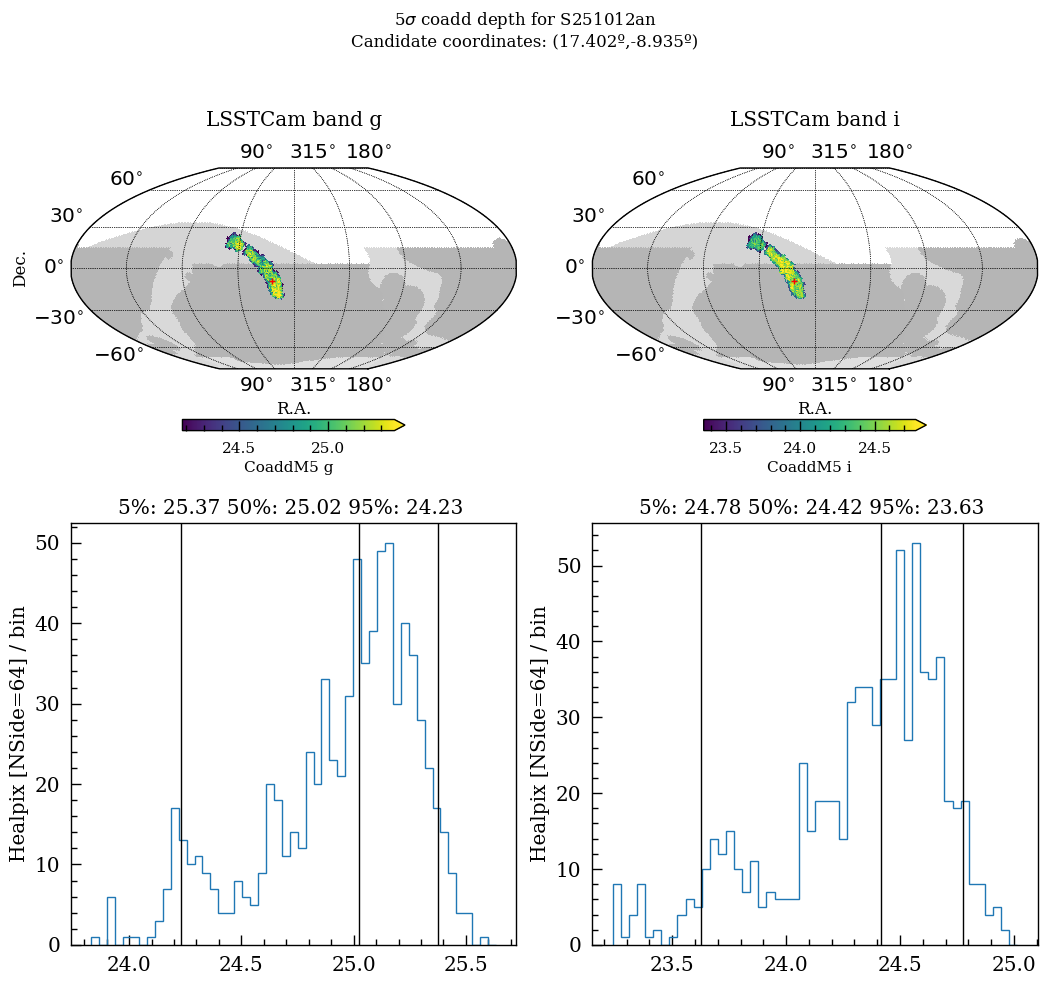

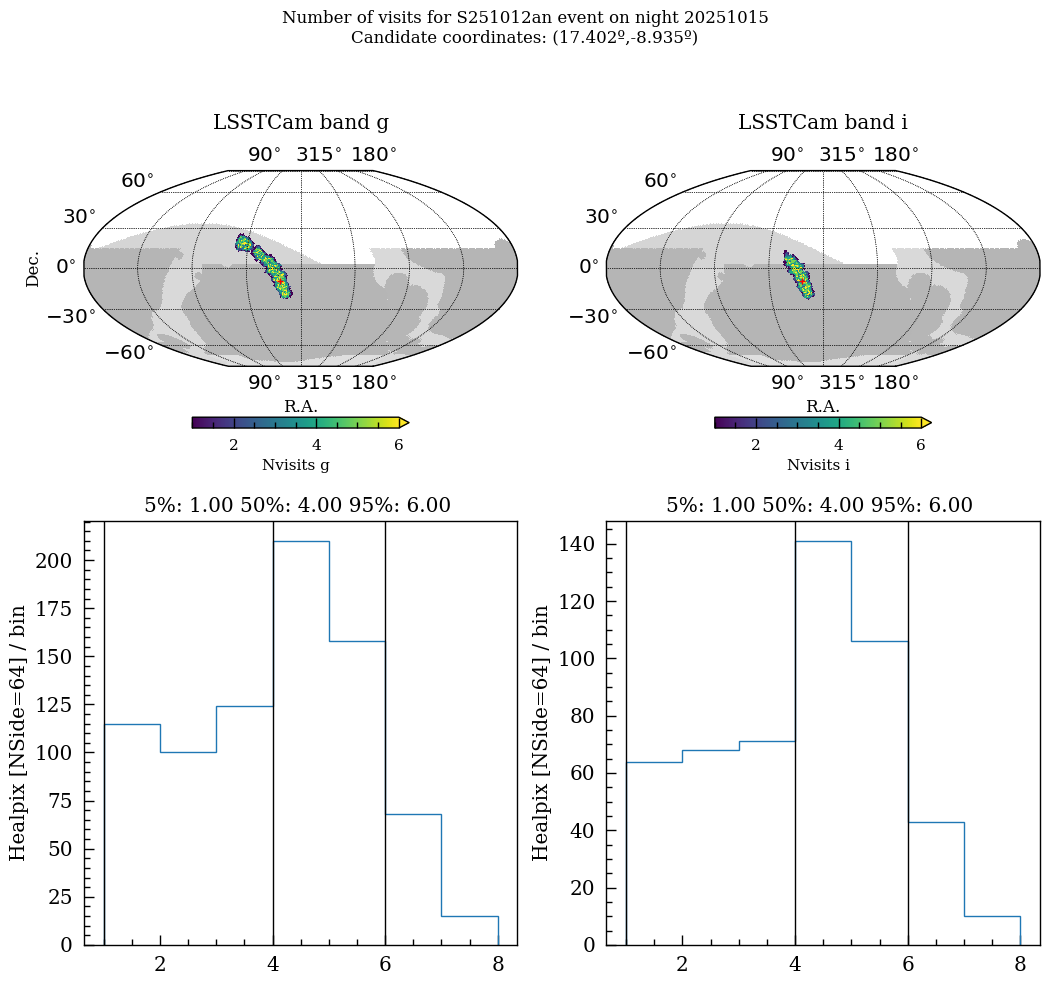

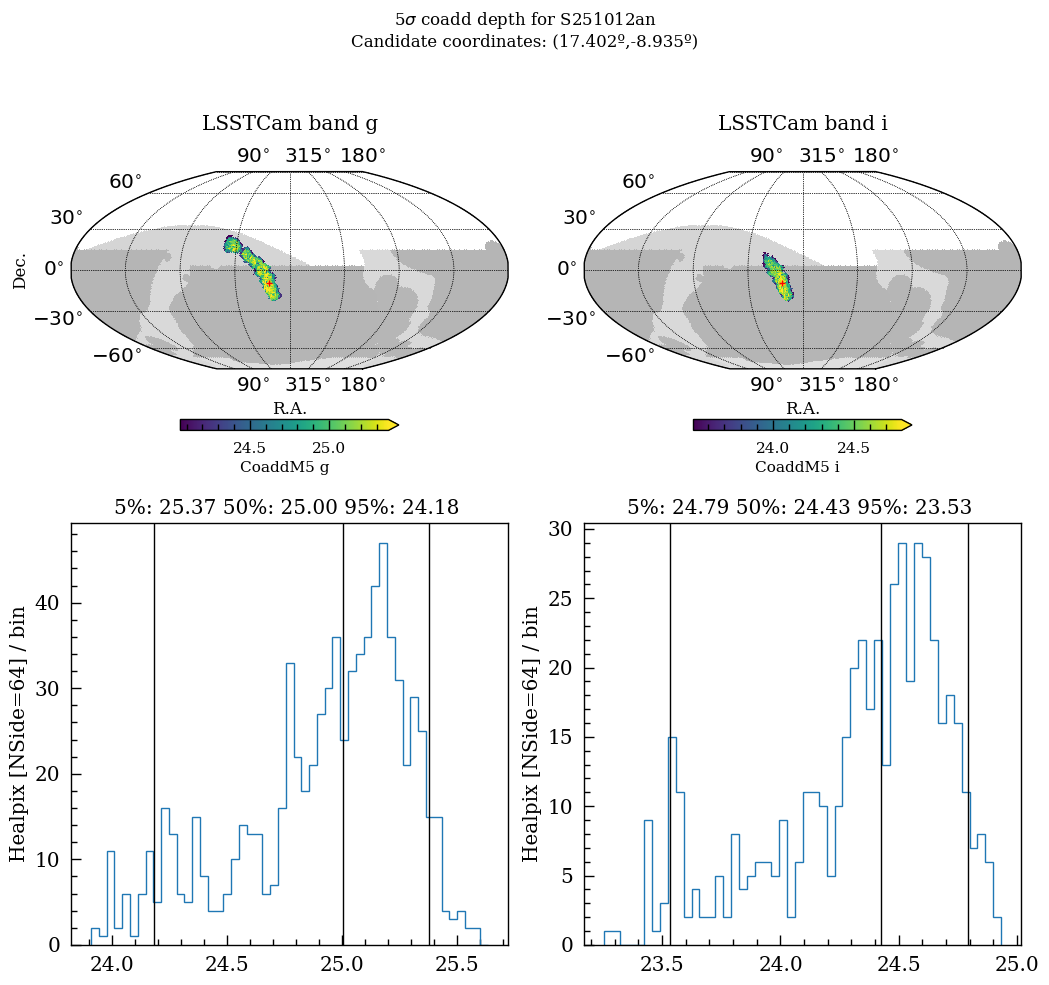

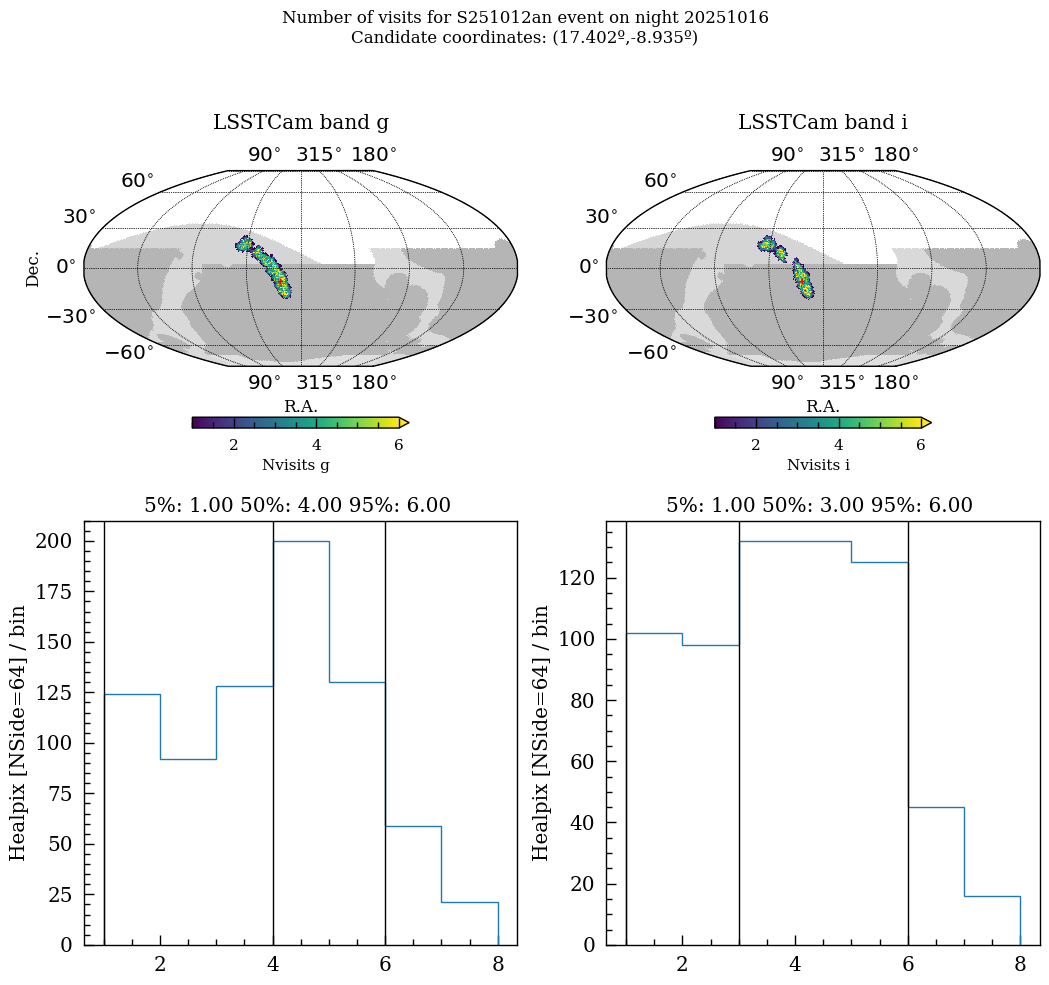

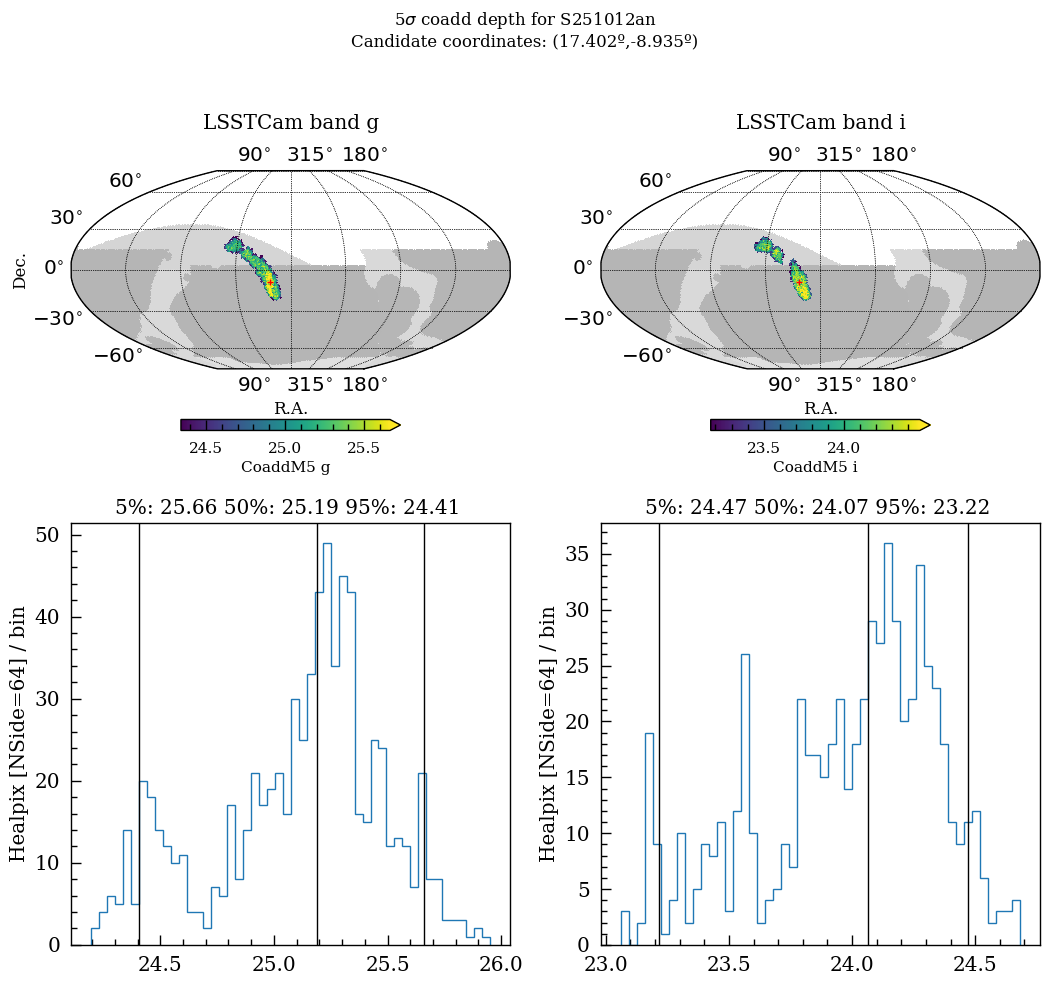

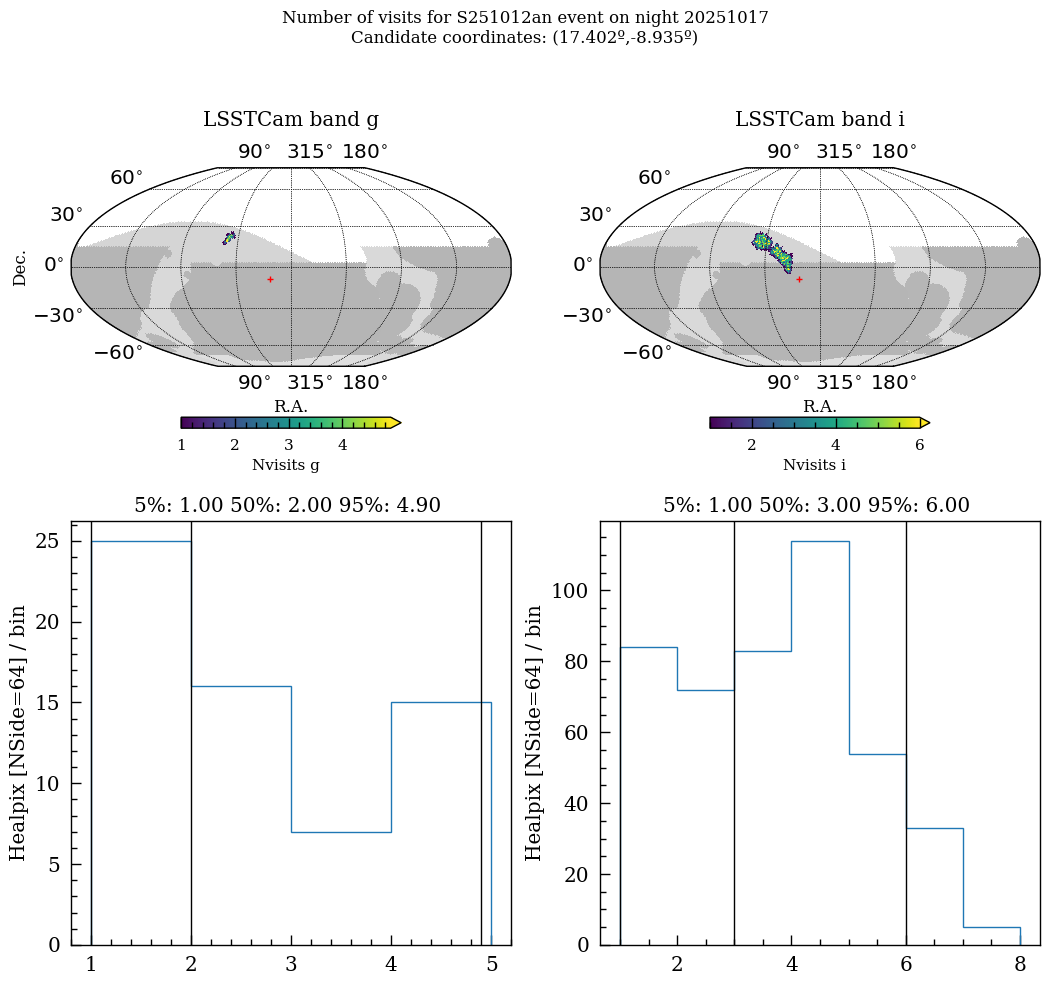

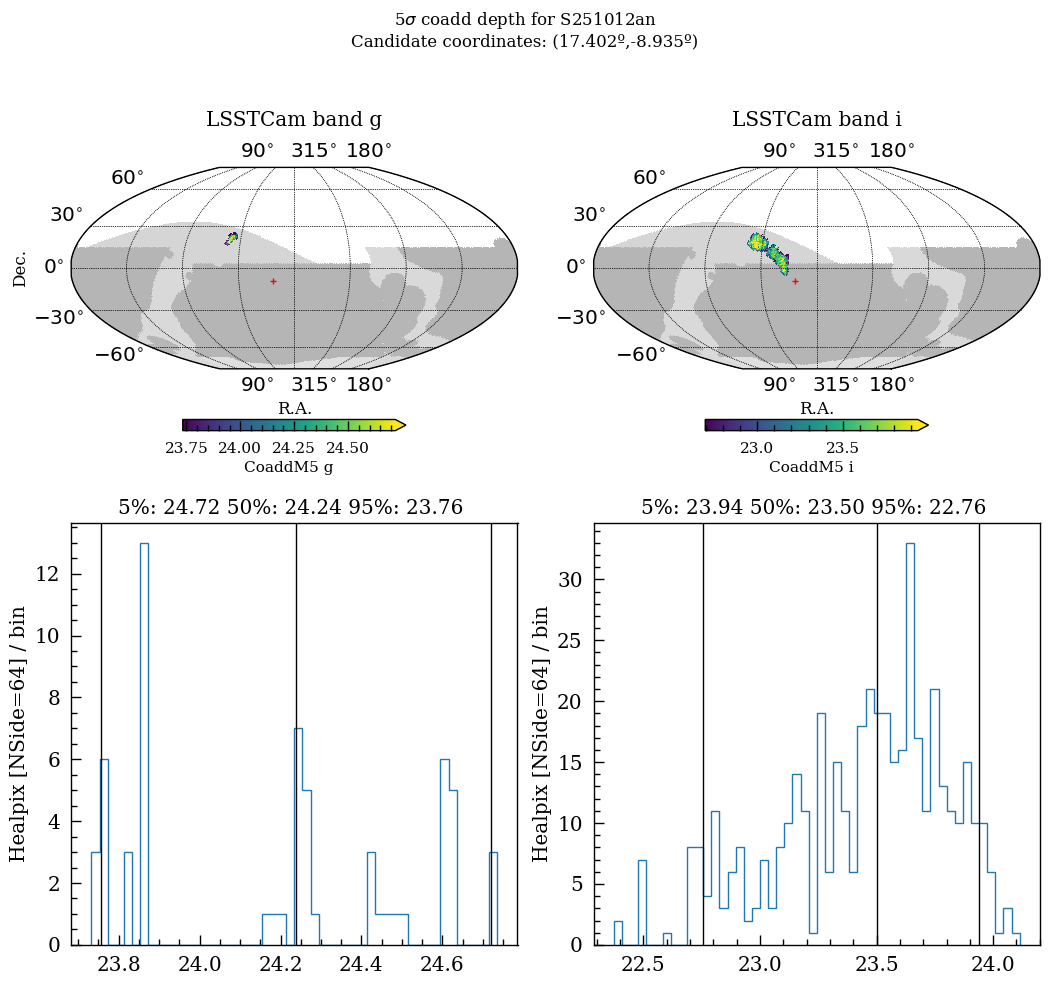

In [37]:
run_calc = True
for night in ToO_obs_days:
    nightMask = (
        np.array(
            [np.datetime_as_string(x, unit="D").replace("-", "") for x in numpyTimeArr]
        )
        == night
    )
    if run_calc:
        nvisits = {}
        coadd = {}
        m_nvis = maf.CountMetric(col="observationStartMJD", metric_name="Nvisits")
        m_coadd = maf.Coaddm5Metric(m5_col="fiveSigmaDepth")
        s = maf.HealpixSlicer(
            nside=64,
            lon_col="fieldRA",
            lat_col="fieldDec",
            rot_sky_pos_col_name="rotSkyPos",
        )
        for b in ["u", "g", "r", "i", "z", "y", "all"]:
            constraint = f"{b}"
            if b == "all":
                opsvis = ToO_obs_df[nightMask].to_records()
            else:
                opsvis = ToO_obs_df[nightMask].query("band == @b").to_records()
            nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
            coadd[b] = maf.MetricBundle(m_coadd, s, constraint)
            g = maf.MetricBundleGroup(
                {f"nvisits {b}": nvisits[b], f"coadd {b}": coadd[b]}, None
            )
            if len(opsvis) > 0:
                g.run_current(constraint, opsvis)
    # Make plots
    fig1 = plot_band_visits(
        nvisits,
        ["u", "g", "r", "i", "z", "y"],
        testEvent,
        plot,
        out_dir=".",
        save=False,
        nside=64,
        plotType="mcbryde",
        title=f"Number of visits for {testEvent['source']} event on night {night}",
        makeHist=True,
    )
    fig2 = plot_band_visits(
        coadd,
        ["u", "g", "r", "i", "z", "y"],
        testEvent,
        plot,
        out_dir=".",
        save=False,
        nside=64,
        plotType="mcbryde",
        title=f"5$\sigma$ coadd depth for {testEvent['source']}",
        makeHist=True,
        reverseStats=True
    )

### Make NVisit and 5$\sigma$ calculations on targeted ToO only visits, separated by night

In [38]:
ToODF = targets[[x.lower().__contains__("gw") for x in targets["target_name"]]]
testTime = Time(ToODF["mjd"], format="mjd").to_datetime()
numpyTimeArr = testTime.astype(np.datetime64)
ToO_obs_days = np.unique(
    [np.datetime_as_string(x, unit="D").replace("-", "") for x in numpyTimeArr]
)
day_obs, ToO_obs_days, eventTriggerTime

(20251011,
 array(['20251013', '20251014', '20251015', '20251016', '20251017'],
       dtype='<U8'),
 numpy.datetime64('2025-10-12T05:24:08.023000'))

In [39]:
ToO_hp_id = hp.ang2pix(
    64, np.rad2deg(testEvent["injRa"]), np.rad2deg(testEvent["injDec"]), lonlat=True
)

In [40]:
run_calc = True

vis_ToO_night = {}
coadd_ToO_night = {}

for night in ToO_obs_days:
    nightMask = (
        np.array(
            [np.datetime_as_string(x, unit="D").replace("-", "") for x in numpyTimeArr]
        )
        == night
    )
    if run_calc:
        nvisits = {}
        coadd = {}
        nvisits_ToO = {}
        coadd_ToO = {}
        m_nvis = maf.CountMetric(col="observationStartMJD", metric_name="Nvisits")
        m_coadd = maf.Coaddm5Metric(m5_col="fiveSigmaDepth")
        s = maf.HealpixSlicer(
            nside=64,
            lon_col="fieldRA",
            lat_col="fieldDec",
            rot_sky_pos_col_name="rotSkyPos",
        )
        for b in ["r", "i", "g", "u", "z", "y", "all"]:
            constraint = f"{b}"
            if b == "all":
                opsvis = ToO_obs_df[nightMask].to_records()
            else:
                opsvis = ToO_obs_df[nightMask].query("band == @b").to_records()
            nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
            coadd[b] = maf.MetricBundle(m_coadd, s, constraint)
            g = maf.MetricBundleGroup(
                {f"nvisits {b}": nvisits[b], f"coadd {b}": coadd[b]}, None
            )
            if len(opsvis) > 0:
                g.run_current(constraint, opsvis)

        # Get the information at the healpix id of the candidate
        for dic1, dic2, name in zip(
            [nvisits, coadd], [nvisits_ToO, coadd_ToO], ["nVisits", "coaddM5"]
        ):
            for b in dic1.keys():
                if np.array(dic1[b].metric_values).all() != None:
                    dic2[b] = dic1[b].metric_values[ToO_hp_id]

        vis_ToO_night[np.datetime64(rn_dayobs.day_obs_to_date(night))] = nvisits_ToO
        coadd_ToO_night[np.datetime64(rn_dayobs.day_obs_to_date(night))] = coadd_ToO

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


/Users/sean/.local/share/mamba/envs/surveySim/lib/python3.10/site-packages/numpy/core/shape_base.py:65: UserWarning: Warning: converting a masked element to nan.
  ary = asanyarray(ary)


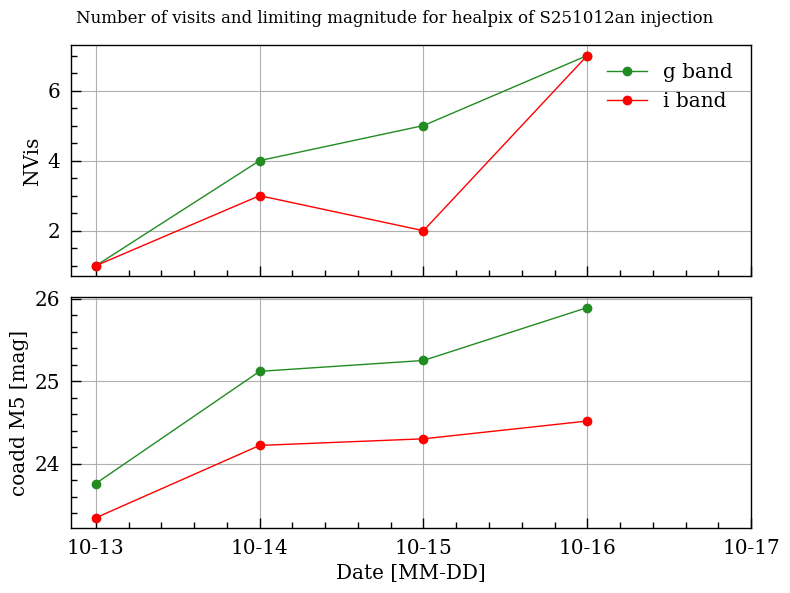

In [41]:
# Make plots
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
# twinx = axs[0].twinx()

for b in ToO_bands_plusAll:
    if b == "all":
        # nights = []
        # num_visits = []
        # for night in nvisits_ToO_night.keys():
        #     try:
        #         num_visits.append(vis_ToO_night[night][b])
        #         nights.append(night)
        #     except:
        #         pass
        #     twinx.plot(nights,num_visits,"-o",label=f"All bands")
        pass
    else:
        nights = []
        num_visits = []
        coadd_night = []
        for night in vis_ToO_night.keys():
            try:
                num_visits.append(vis_ToO_night[night][b])
                coadd_night.append(coadd_ToO_night[night][b])
                nights.append(night)
            except:
                pass
        axs[0].plot(nights, num_visits, "-o", color=bandColors[b], label=f"{b} band")
        axs[1].plot(nights, coadd_night, "-o", color=bandColors[b], label=f"{b} band")

axs[0].legend()
axs[0].set_ylabel("NVis")
axs[1].set_ylabel("coadd M5 [mag]")
axs[1].set_xlabel("Date [MM-DD]")

for a in axs:
    a.grid()
    a.set_xticks(list(vis_ToO_night.keys()))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
fig.suptitle(
    f"Number of visits and limiting magnitude for healpix of {testEvent['source']} injection"
)
fig.tight_layout()

### Make NVisit and 5$\sigma$ calculations on targeted ToO only visits, separated by desired epoch

In [42]:
triggeredSurvey = np.array(scheduler.survey_lists[0])[
    [
        (too_server.targeto_o_list[0].too_type in x.too_types_to_follow)
        for x in scheduler.survey_lists[0]
    ]
][0]
num_epochs = len(
    triggeredSurvey.times
)  # This is the desired number of epochs for the ToO

In [43]:
run_calc = True

vis_ToO_epoch = {}
coadd_ToO_epoch = {}

for epoch in range(num_epochs):
    epochMask = np.array(
        [
            (x.startswith("ToO") and x.__contains__(f"_i{epoch}"))
            for x in ToO_obs_df["scheduler_note"]
        ]
    )
    if run_calc:
        nvisits = {}
        coadd = {}
        nvisits_ToO = {}
        coadd_ToO = {}
        m_nvis = maf.CountMetric(col="observationStartMJD", metric_name="Nvisits")
        m_coadd = maf.Coaddm5Metric(m5_col="fiveSigmaDepth")
        s = maf.HealpixSlicer(
            nside=64,
            lon_col="fieldRA",
            lat_col="fieldDec",
            rot_sky_pos_col_name="rotSkyPos",
        )
        for b in ["r", "i", "g", "u", "z", "y", "all"]:
            constraint = f"{b}"
            if b == "all":
                opsvis = ToO_obs_df[epochMask].to_records()
            else:
                opsvis = ToO_obs_df[epochMask].query("band == @b").to_records()
            nvisits[b] = maf.MetricBundle(m_nvis, s, constraint)
            coadd[b] = maf.MetricBundle(m_coadd, s, constraint)
            g = maf.MetricBundleGroup(
                {f"nvisits {b}": nvisits[b], f"coadd {b}": coadd[b]}, None
            )
            if len(opsvis) > 0:
                g.run_current(constraint, opsvis)

        # Get the information at the healpix id of the candidate
        for dic1, dic2, name in zip(
            [nvisits, coadd], [nvisits_ToO, coadd_ToO], ["nVisits", "coaddM5"]
        ):
            for b in dic1.keys():
                if np.array(dic1[b].metric_values).all() != None:
                    dic2[b] = dic1[b].metric_values[ToO_hp_id]

        vis_ToO_epoch[epoch] = nvisits_ToO
        coadd_ToO_epoch[epoch] = coadd_ToO

Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes
Healpix slicer using NSIDE=64, approximate resolution 54.967783 arcminutes


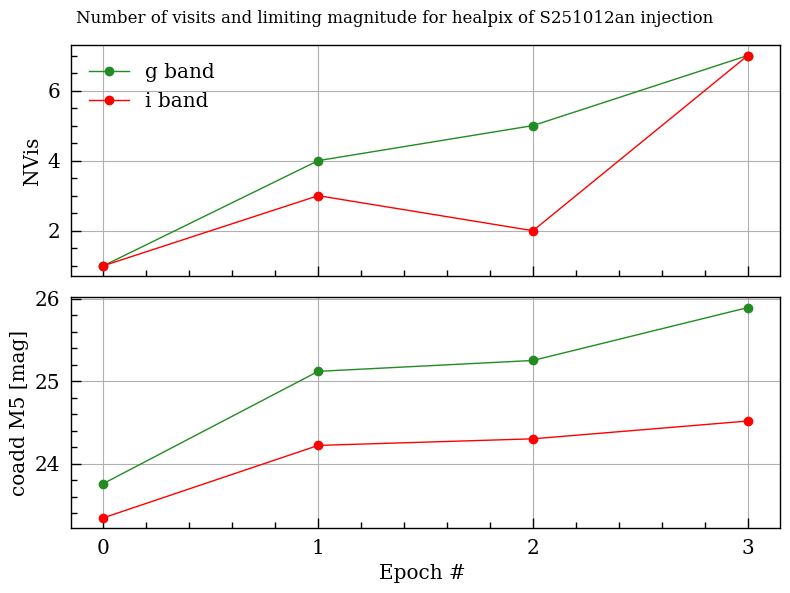

In [44]:
# Make plots
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
# twinx = axs[0].twinx()

for b in ToO_bands_plusAll:
    if b == "all":
        pass
    else:
        epochs = []
        num_visits = []
        coadd_epoch = []
        epochTime = []
        for epoch in vis_ToO_epoch.keys():
            try:
                num_visits.append(vis_ToO_epoch[epoch][b])
                coadd_epoch.append(coadd_ToO_epoch[epoch][b])
                nights.append(night)
                epochTime.append(epoch)
            except:
                pass
        axs[0].plot(epochTime, num_visits, "-o", color=bandColors[b], label=f"{b} band")
        axs[1].plot(
            epochTime, coadd_epoch, "-o", color=bandColors[b], label=f"{b} band"
        )

axs[0].legend()
axs[0].set_ylabel("NVis")
axs[1].set_ylabel("coadd M5 [mag]")
axs[1].set_xlabel("Epoch # ")

for a in axs:
    a.grid()
    a.set_xticks(list(vis_ToO_epoch.keys()))
    # a.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.suptitle(
    f"Number of visits and limiting magnitude for healpix of {testEvent['source']} injection"
)
fig.tight_layout()

## Localization probability visualizations

### Define the skymap class

In [45]:
import math


class Skymap:
    # Shamelessly stolen from https://github.com/scimma/rubin-ToO-producer/blob/main/forward_alerts.py#L127
    def __init__(self, densities, u_indices, drop_trivial_probabilities: bool = True):
        """
        Construct a map from arrays of probability densities and healpix UNIQ ordering indices.
        Data in the map will be re-ordered with entries sorted in order of decreasing density.

        Args:
            drop_trivial_probabilities: If set, all of the pixels whose contributions to the total
                                        probability are so small that the sum of probabilities from
                                        higher probability pixels is one to within floating-point
                                        epsilon have their probability densities set to zero, making
                                        the map more compressible.
        """
        self.data = np.array(
            sorted(zip(densities, u_indices), key=lambda entry: -entry[0]),
            dtype=[("prob_density", "f8"), ("uniq_index", "i8")],
        )

        # Many entries contribute tiny probabilities which should be unimportant.
        # We seek to replace these with zeros, which will hopefully form large, compressible
        # runs when we are forced to make a single (maximal) order map.
        # Sum probability until the total reaches one. This will generally occur before the end of
        # the data due to limited floating-point precision, although we use Kahan summation to avoid
        # it happening unduly quickly; values after this can be considered irrelevant since they
        # are each too small to cause the sum to increase further (although it might still
        # increase it if the Kahan algorithm were continued and they collectively exceed
        # floating-point epsilon).
        summed_prob = KahanAdder()
        comp = 0
        # A cache of the areas of pixels at all relevant orders
        self.pixel_areas = {}
        for entry in self.data:
            order = math.floor(math.log2(entry[1] / 4) / 2)
            if drop_trivial_probabilities and summed_prob >= 1.0:
                entry[0] = 0
                continue
            if order not in self.pixel_areas:
                self.pixel_areas[order] = math.pi / (3 << (order << 1))
            area = self.pixel_areas[order]
            prob = entry[0] * area
            summed_prob += prob
        # print("Order range:",min(self.pixel_areas.keys()),'-',max(self.pixel_areas.keys()))

    def area_for_probability(self, target_probability: float):
        """
        Compute the area on the sky subtended by the highest density portion of the map which
        sums to the target probability.

        Return: The sky area, and the minimum declination, in radians, touched by that area
        """
        summed_prob = KahanAdder()
        summed_area = KahanAdder()
        n_indices = {}
        for p_dens, u_idx in self.data:
            order = math.floor(math.log2(u_idx / 4) / 2)
            area = self.pixel_areas[order]
            prob = p_dens * area
            summed_prob += prob
            summed_area += area
            n_idx = u_idx - (4 << (2 * order))
            if 1 << order not in n_indices:
                n_indices[1 << order] = [n_idx]
            else:
                n_indices[1 << order].append(n_idx)
            if summed_prob >= target_probability:
                break
        # Each call to boundaries_lonlat and fixing its output to be a usable form is very slow.
        # This can be worked around by having it process an array of pixels, b ut it cannot handle
        # more than one value of 'nside' at a time, so it must be called once for each order of
        # pixels to be checked.
        min_dec = 100
        for nside in n_indices.keys():
            # extract the declinations (latitudes) of all pixel corners, in radians
            corner_decs = (
                boundaries_lonlat(n_indices[nside], 1, nside, "nested")[1]
                .to_value()
                .flatten()
            )
            min_corner_dec = np.min(corner_decs)
            if min_corner_dec < min_dec:
                min_dec = min_corner_dec
        return summed_area.sum, min_dec

    def make_flat_map(self):
        # first, figure out how many pixels it must be from its order, which must be the maximum
        # order in the original map
        flat_order = max(self.pixel_areas.keys())
        flat_n_npixels = 12 << (flat_order << 1)

        flat_map = np.zeros(flat_n_npixels)

        # next, iterate over the original map, and copy its data into all corresponding pixels
        # of the flat map
        for p_dens, u_idx in self.data:
            # u_idx is the original pixel's UNIQ index
            order = math.floor(math.log2(u_idx / 4) / 2)
            # the original pixel's NESTED ordering index, within its order
            n_idx = u_idx - (4 << (2 * order))
            # each unit of increase in order adds two bits to the child pixel indices
            min_idx = n_idx << (2 * (flat_order - order))
            # the increase in order splits the original pixel into this many pixels
            idx_range = 1 << (2 * (flat_order - order))
            flat_map[min_idx : (min_idx + idx_range)] = p_dens

        return flat_map

    def make_flat_binary_map(self, target_probability: float, target_order=None):
        # first, figure out how many pixels it must be from its order, which must be the maximum
        # order in the original map
        if target_order is None:
            target_order = max(self.pixel_areas.keys())
        flat_n_npixels = 12 << (target_order << 1)
        # print(f"Making order {target_order} map with {flat_n_npixels} pixels")

        flat_map = np.zeros(flat_n_npixels, dtype=bool)

        # next, iterate over the original map, and writing ones for all pixels which are above the
        # target threshold
        summed_prob = KahanAdder()
        for p_dens, u_idx in self.data:
            # u_idx is the original pixel's UNIQ index
            order = math.floor(math.log2(u_idx / 4) / 2)

            # the original pixel's NESTED ordering index, within its order
            n_idx = u_idx - (4 << (2 * order))
            if order < target_order:
                # each unit of increase in order adds two bits to the child pixel indices
                min_idx = n_idx << (2 * (target_order - order))
                # the increase in order splits the original pixel into this many pixels
                idx_range = 1 << (2 * (target_order - order))
                flat_map[min_idx : (min_idx + idx_range)] = True
            else:
                # throw away two bits for each unit of difference in order to find parent pixel
                p_idx = n_idx >> (2 * (order - target_order))
                flat_map[p_idx] = True

            area = self.pixel_areas[order]
            prob = p_dens * area
            summed_prob += prob

            if summed_prob >= target_probability:
                break

        return flat_map


class KahanAdder:
    # Shamelessly stolen from https://github.com/scimma/rubin-ToO-producer/blob/main/forward_alerts.py#L127
    def __init__(self):
        self.sum = 0.0
        self.comp = 0.0

    def __float__(self):
        return self.sum

    def __iadd__(self, value):
        y = float(value) - self.comp
        t = self.sum + y
        self.comp = (t - self.sum) - y
        self.sum = t
        return self

    def __eq__(self, value):
        return self.sum == value

    def __ne__(self, value):
        return self.sum != value

    def __lt__(self, value):
        return self.sum < value

    def __le__(self, value):
        return self.sum <= value

    def __gt__(self, value):
        return self.sum > value

    def __ge__(self, value):
        return self.sum >= value

### Convert multi-order map to flat map for rapid parsing

In [46]:
skymap = read_sky_map(
    f"../mdc_data/skymaps/{testEvent['source']}_bayestar.multiorder.fits", moc=True
)
parsed_skymap = Skymap(skymap["PROBDENSITY"], skymap["UNIQ"])
flatSkyMap_nest = parsed_skymap.make_flat_map()
flatSkyMap_ring = flatSkyMap_nest[
    hp.ring2nest(hp.get_nside(flatSkyMap_nest), np.arange(len(flatSkyMap_nest)))
]
flatSkyMap_ring_norm = np.array(flatSkyMap_ring / sum(flatSkyMap_ring))

### Plot cumulative probability coverage

Area covered in g band: 716.222 deg^2
Area covered in i band: 716.222 deg^2


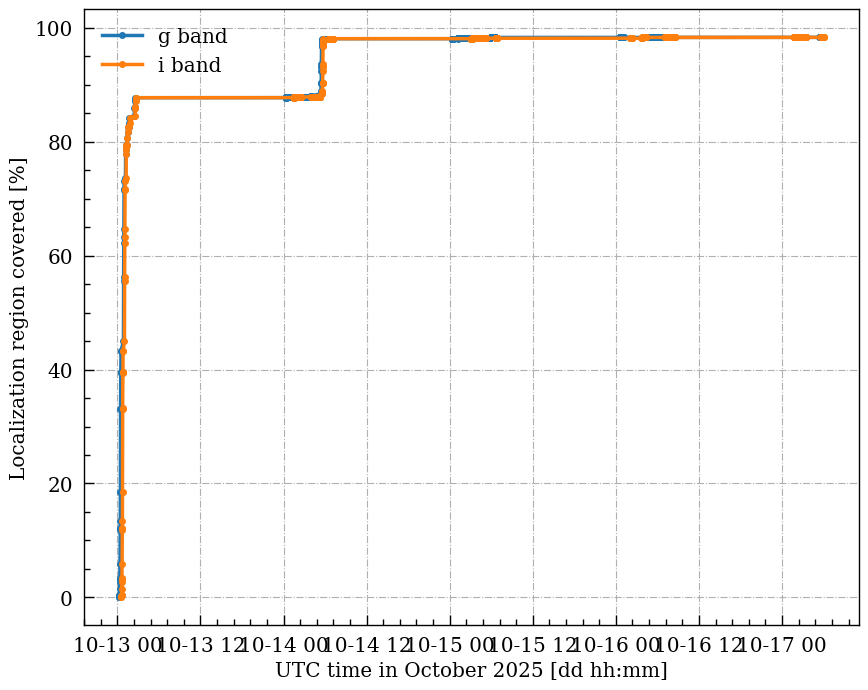

In [47]:
plot_cumulative = True
if plot_cumulative:
    fig, ax = plt.subplots(figsize=[10, 8])
    for band in np.unique(ToODF["band"]):
        startMap = copy.deepcopy(flatSkyMap_ring_norm)
        startMap2 = copy.deepcopy(flatSkyMap_ring_norm)
        cumProb = [0]
        subsetDF = ToODF[ToODF["band"] == band]
        timeOfObs = [
            np.datetime64(Time(subsetDF.iloc[0]["mjd"], format="mjd").to_datetime())
            - np.timedelta64(1, "m")
        ]
        for ra, dec, tim in zip(
            subsetDF["RA"],
            subsetDF["dec"],
            Time(subsetDF["mjd"], format="mjd").to_datetime().astype(np.datetime64),
        ):
            timeOfObs.append(tim)
            centerVec = hp.ang2vec(np.rad2deg(ra), np.rad2deg(dec), lonlat=True)
            disc_indices = hp.query_disc(
                hp.get_nside(startMap), centerVec, 1.75 * np.pi / 180
            )
            cumProb.append(sum(startMap[disc_indices]))
            startMap[disc_indices] = 0
            startMap2[disc_indices] = 1
        ax.plot(
            timeOfObs,
            100 * np.cumsum(cumProb),
            "-o",
            label=f"{band} band",
            linewidth=2.5,
            markersize=4,
        )
        print(
            f"Area covered in {band} band: {len(startMap[startMap2==1])*hp.nside2pixarea(hp.get_nside(startMap),degrees=True):.3f} deg^2"
        )

    ax.legend(framealpha=1)
    ax.grid(ls="-.")
    ax.set_xlabel("UTC time in October 2025 [dd hh:mm]")
    ax.set_ylabel("Localization region covered [%]")

### Plot per-night probability coverage

Area covered in g band on MJD=60961.0: 406.67 deg^2
Localization area covered: 87.7414%
Area covered in i band on MJD=60961.0: 406.67 deg^2
Localization area covered: 87.7414%
Area covered in g band on MJD=60962.0: 661.45 deg^2
Localization area covered: 98.1024%
Area covered in i band on MJD=60962.0: 661.45 deg^2
Localization area covered: 98.1024%
Area covered in g band on MJD=60963.0: 662.82 deg^2
Localization area covered: 98.2772%
Area covered in i band on MJD=60963.0: 424.09 deg^2
Localization area covered: 84.8779%
Area covered in g band on MJD=60964.0: 628.66 deg^2
Localization area covered: 98.0816%
Area covered in i band on MJD=60964.0: 545.30 deg^2
Localization area covered: 92.2518%
Area covered in g band on MJD=60965.0: 52.02 deg^2
Localization area covered: 1.7959%
Area covered in i band on MJD=60965.0: 375.26 deg^2
Localization area covered: 27.3054%


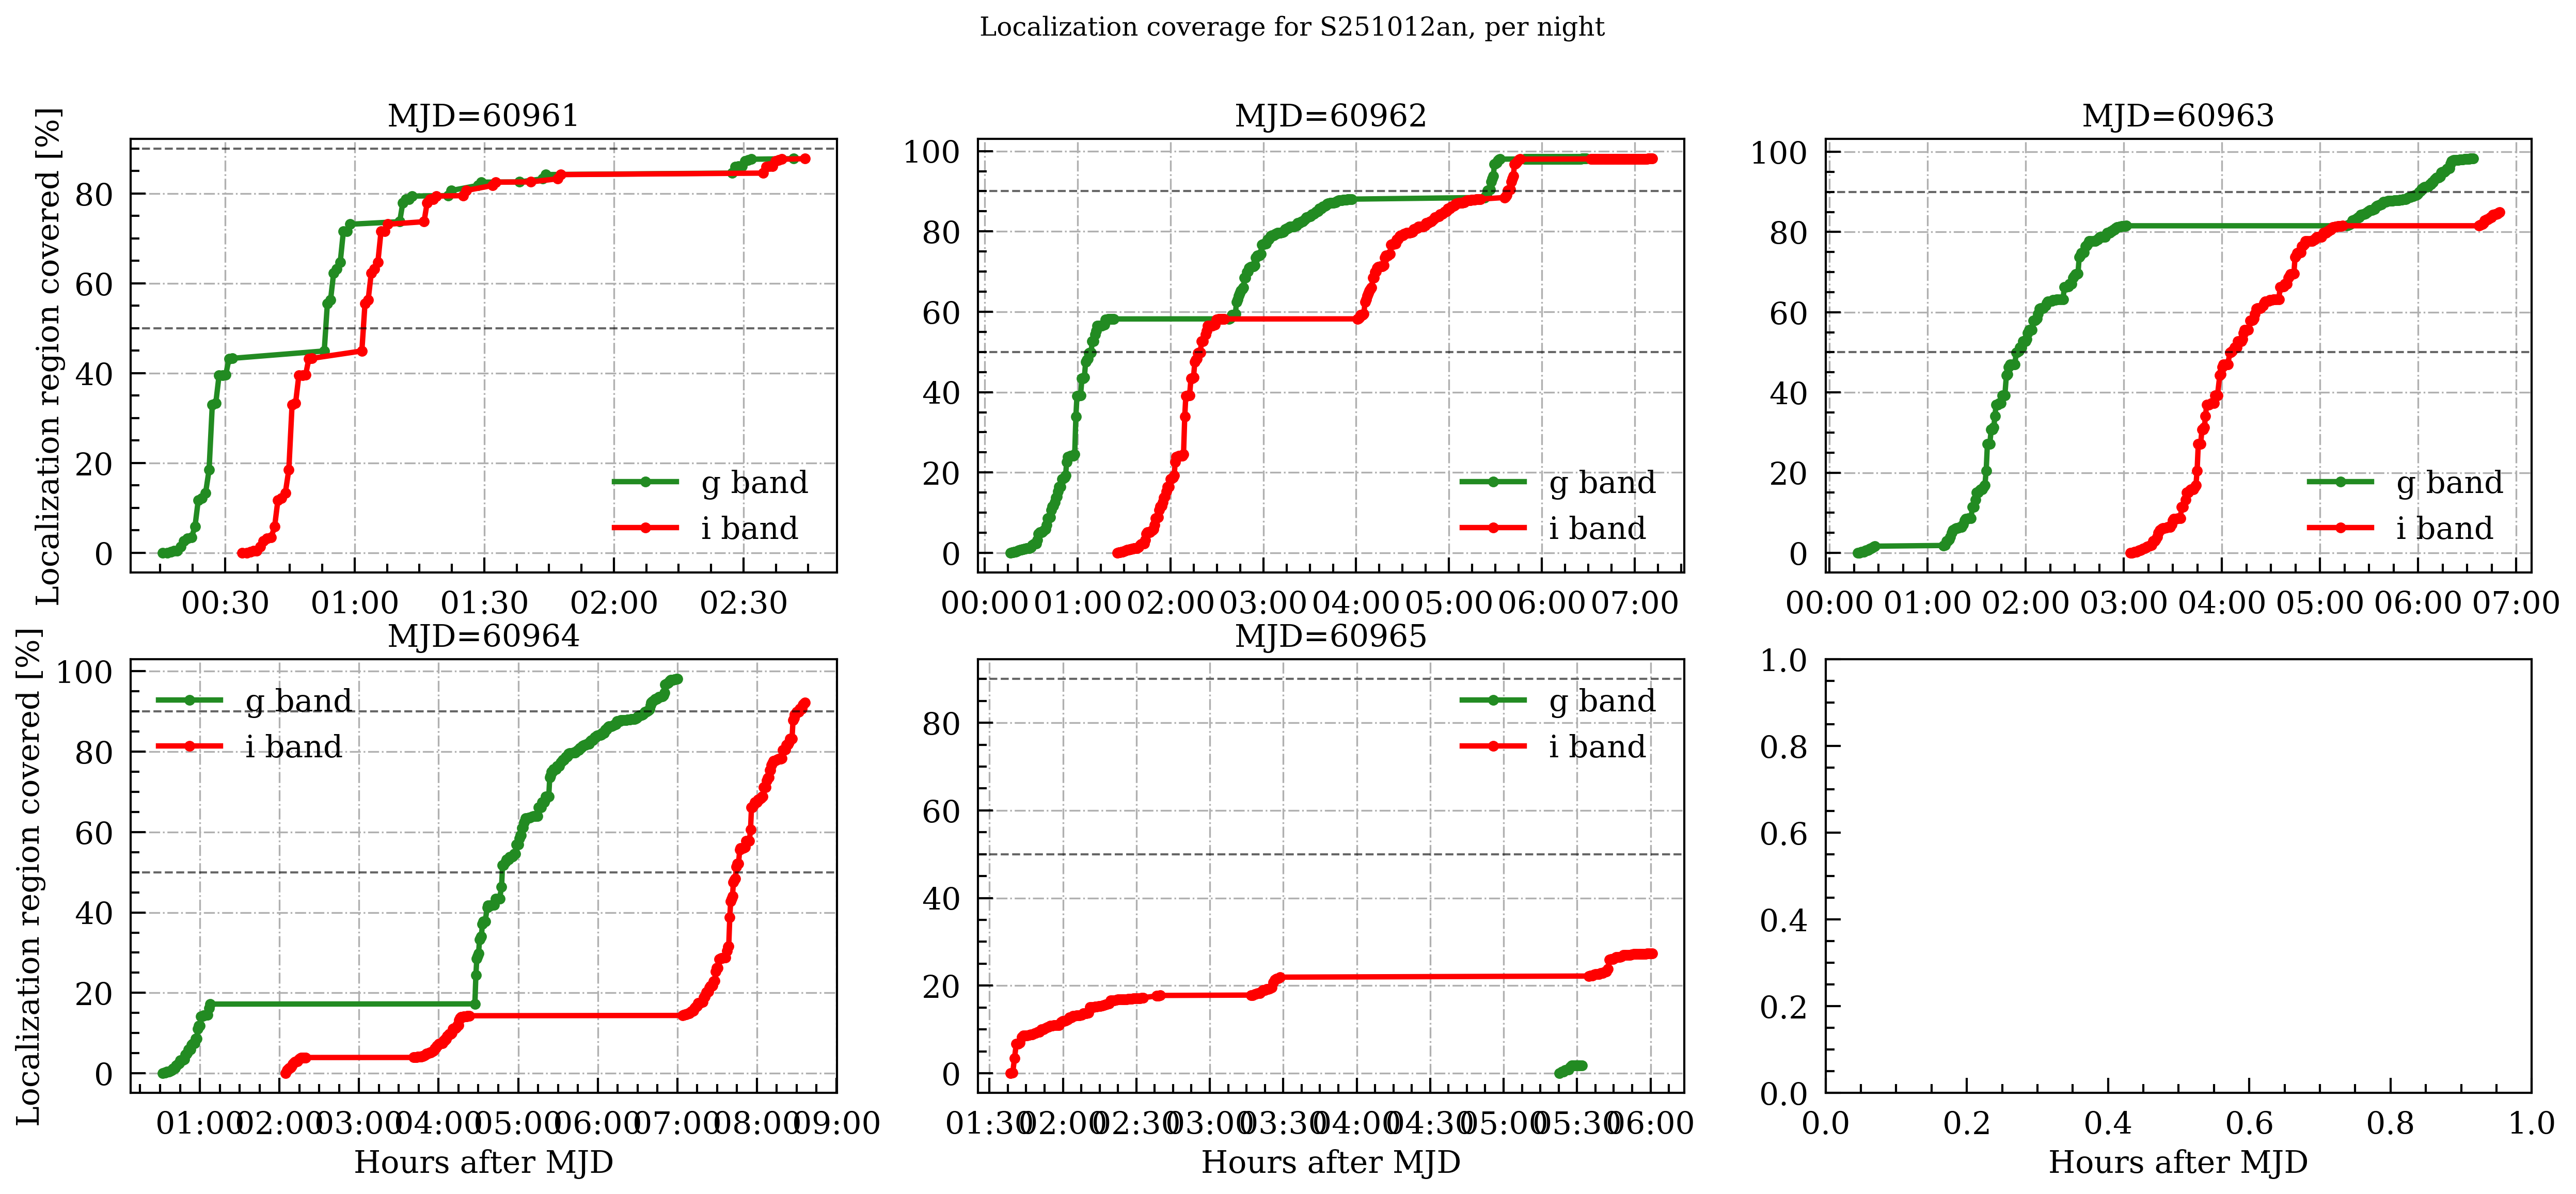

In [48]:
plot_per_night = True
if plot_per_night:
    fig, axs = plt.subplots(
        2,
        len(np.unique(np.floor(ToODF["mjd"]))) // 2
        + len(np.unique(np.floor(ToODF["mjd"]))) % 2,
        figsize=[20, 8],
        dpi=300,
    )

    # fig,axs = plt.subplots(1,len(np.unique(np.floor(ToODF["mjd"]))),figsize=[20,4])
    for floorMJD, ax in zip(np.unique(np.floor(ToODF["mjd"])), axs.flatten()):

        dayDF = ToODF[np.floor(ToODF["mjd"]) == floorMJD]

        for band in np.unique(dayDF["band"]):
            startMap = copy.deepcopy(flatSkyMap_ring_norm)
            startMap2 = copy.deepcopy(flatSkyMap_ring_norm)
            cumProb = [0]
            subsetDF = dayDF[dayDF["band"] == band]
            timeOfObs = [
                np.datetime64(Time(subsetDF.iloc[0]["mjd"], format="mjd").to_datetime())
                - np.timedelta64(1, "m")
            ]
            for ra, dec, tim in zip(
                subsetDF["RA"],
                subsetDF["dec"],
                Time(subsetDF["mjd"], format="mjd").to_datetime().astype(np.datetime64),
            ):
                timeOfObs.append(tim)
                centerVec = hp.ang2vec(np.rad2deg(ra), np.rad2deg(dec), lonlat=True)
                disc_indices = hp.query_disc(
                    hp.get_nside(startMap), centerVec, 1.75 * np.pi / 180
                )
                cumProb.append(sum(startMap[disc_indices]))
                startMap[disc_indices] = 0
                startMap2[disc_indices] = 1
            ax.plot(
                timeOfObs,
                100 * np.cumsum(cumProb),
                "-o",
                label=f"{band} band",
                linewidth=2.5,
                markersize=4,
                color=bandColors[band],
            )
            print(
                f"Area covered in {band} band on MJD={floorMJD}: {len(startMap[startMap2==1])*hp.nside2pixarea(hp.get_nside(startMap),degrees=True):.2f} deg^2"
            )
            print(f"Localization area covered: {100*np.cumsum(cumProb)[-1]:0.4f}%")

        ax.legend(framealpha=1)
        # ax.axhline(90,ls='-',color='black')
        ax.grid(ls="-.")
        ax.set_title(f"MJD={int(floorMJD)}")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        for v in [50, 90]:
            ax.axhline(v, color="black", alpha=0.6, ls="--")
    for ax in axs[-1, :]:
        ax.set_xlabel("Hours after MJD")
    for ax in axs[:, 0]:
        ax.set_ylabel("Localization region covered [%]")
    fig.suptitle(f"Localization coverage for {testEvent['source']}, per night")
    fig.savefig(f"./localization_{testEvent['source']}.jpg", dpi=300)